# Process Mining Analysis — Resources, Roles, Timetables and Activity Distributions

This notebook analyzes four event logs:

- **BAC**
- **BPIC2012**
- **BPIC2017 (before)**
- **BPIC2017 (after)**

using [PM4Py](https://pm4py.fit.fraunhofer.de/). For every dataset the notebook reports:

1. The number of resources involved in the process and how they are grouped into organizational roles.
2. The **case arrival frequency** (how many cases start on each day of the week).
3. The **working-day** and **working-hour** timetables of the main organizational roles.
4. The **duration distribution of every activity** in the log.

The notebook is organized so that all the loading/parsing logic and the plotting logic are defined once (as reusable functions) and then applied to each of the four datasets, instead of repeating the same code multiple times as in the original exploratory notebook.

## 1. Environment setup

Install and import the libraries needed for the analysis: PM4Py for process mining, pandas/numpy for data handling, and matplotlib for plotting.

In [25]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import pm4py

# Fixed order used for every "day of week" plot
WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

## 2. Dataset paths configuration

The four logs are stored as `train_data.csv` files inside a `case_studies/<dataset>/` folder. This mirrors the exact path-resolution logic already used in `MAE_residual_visualisation.ipynb`: if the `case_studies` folder is not found relative to the current working directory, the notebook falls back to the fixed project path used during development.

In [26]:
base_dir = Path.cwd()
if not (base_dir / "case_studies").exists():
    base_dir = Path("C:/Users/Utente/Desktop/tesi magistrale/Code/2-gelmini-multi").resolve()


def build_path(dataset_name: str, file_name: str, subfolder: str = "") -> str:
    """Build the path to a file belonging to a given case study.

    Mirrors the logic used in MAE_residual_visualisation.ipynb.
    """
    base_path = base_dir / "case_studies" / dataset_name
    if subfolder:
        base_path = base_path / subfolder
    return str(base_path / file_name)


# Mapping between a display name and the folder name used on disk
case_study_map = {
    "BAC": "BAC",
    "BPIC2012": "BPI12",
    "BPIC2017_Before": "bpi17_before",
    "BPIC2017_After": "bpi17_after",
}

# CSV log path for each dataset
dataset_paths = {
    display_name: build_path(folder_name, "train_data.csv")
    for display_name, folder_name in case_study_map.items()
}

dataset_paths

{'BAC': 'C:\\Users\\Utente\\Desktop\\tesi magistrale\\Code\\2-gelmini-multi\\case_studies\\BAC\\train_data.csv',
 'BPIC2012': 'C:\\Users\\Utente\\Desktop\\tesi magistrale\\Code\\2-gelmini-multi\\case_studies\\BPI12\\train_data.csv',
 'BPIC2017_Before': 'C:\\Users\\Utente\\Desktop\\tesi magistrale\\Code\\2-gelmini-multi\\case_studies\\bpi17_before\\train_data.csv',
 'BPIC2017_After': 'C:\\Users\\Utente\\Desktop\\tesi magistrale\\Code\\2-gelmini-multi\\case_studies\\bpi17_after\\train_data.csv'}

## 3. Loading the event logs

Each `train_data.csv` file already uses PM4Py-compatible column names (`case:concept:name`, `concept:name`, `org:resource`, `start:timestamp`, `time:timestamp`, ...), as shown in `header_logs.txt`. This means every log can be converted directly into a PM4Py `EventLog` object, without the extra cleaning/renaming steps that were needed for the original raw log.

In [3]:
def load_event_log(csv_path: str):
    """Read a PM4Py-compatible CSV log and convert it into a PM4Py EventLog object."""
    df = pd.read_csv(csv_path)

    # format="ISO8601" correctly handles timestamps with mixed precision
    # (e.g. some rows with microseconds, some without), which happens across
    # the four logs (and even within the same log, e.g. BPIC2012).
    df["start:timestamp"] = pd.to_datetime(df["start:timestamp"], format="ISO8601", utc=True)
    df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], format="ISO8601", utc=True)

    formatted_df = pm4py.format_dataframe(
        df,
        case_id="case:concept:name",
        activity_key="concept:name",
        start_timestamp_key="start:timestamp",
        timestamp_key="time:timestamp",
    )
    return pm4py.convert_to_event_log(formatted_df)


event_logs = {}

for name, path in dataset_paths.items():
    if not Path(path).exists():
        print(f"File not found for {name}: {path}")
        continue
    print(f"Loading {name} ...")
    event_logs[name] = load_event_log(path)

print(f"\nSuccessfully loaded {len(event_logs)} / {len(dataset_paths)} dataset(s): {list(event_logs.keys())}")

Loading BAC ...
Loading BPIC2012 ...
Loading BPIC2017_Before ...
Loading BPIC2017_After ...

Successfully loaded 4 / 4 dataset(s): ['BAC', 'BPIC2012', 'BPIC2017_Before', 'BPIC2017_After']


## 4. Analysis functions

The following helper functions implement the analyses requested for each dataset. They are written once and reused for all four logs.

For performance on the larger logs (BPIC2012, BPIC2017), each dataset is converted to a pandas DataFrame **once**, and all the plots are computed with vectorized pandas operations rather than nested Python loops over every event.

### 4.1 DataFrame helper

Converts a PM4Py `EventLog` into a DataFrame and pre-computes the duration (in minutes) of every event, which is reused by the activity-distribution plots.

In [4]:
def get_log_dataframe(log):
    """Convert a PM4Py EventLog into a DataFrame and add a 'duration_min' column."""
    df = pm4py.convert_to_dataframe(log)
    df["duration_min"] = (df["time:timestamp"] - df["start:timestamp"]).dt.total_seconds() / 60
    return df

### 4.2 Resources and organizational roles

Organizational roles are discovered automatically by PM4Py from the activity/resource relationships in the log (`pm4py.discover_organizational_roles`). For each dataset we print the total number of distinct resources and, for every discovered role, the activities it covers and the resources assigned to it.

In [5]:
def print_resources_and_roles(log, df, dataset_name):
    """Print the total number of resources and how they are grouped into organizational roles."""
    resources = sorted(df["org:resource"].dropna().unique())
    print(f"Total number of distinct resources: {len(resources)}")

    roles = pm4py.discover_organizational_roles(log)
    print(f"Number of discovered organizational roles: {len(roles)}\n")

    for i, role in enumerate(roles):
        role_resources = list(role.originator_importance.keys())
        print(f"Role {i + 1}: activities = {sorted(role.activities)}")
        print(f"    -> {len(role_resources)} resource(s): {role_resources}\n")

    return roles

### 4.3 Case arrival frequency

For each dataset we plot the number of cases whose **first event** starts on each day of the week.

In [6]:
def plot_case_arrival_frequency(df, dataset_name):
    """Bar chart of the number of cases whose first event starts on each weekday."""
    case_start = df.groupby("case:concept:name")["time:timestamp"].min()
    weekday_counts = case_start.dt.day_name().value_counts().reindex(WEEKDAYS, fill_value=0)

    plt.figure(figsize=(12, 6))
    plt.bar(weekday_counts.index, weekday_counts.values, color="steelblue")
    plt.xlabel("Day of week")
    plt.ylabel("Number of cases started")
    plt.title(f"Case Arrival Frequency - {dataset_name}")
    plt.show()

### 4.4 Working-day and working-hour timetables per role

For a given set of resources (typically all the resources belonging to one organizational role) we plot how their events are distributed across the days of the week and across the hours of the day.

In [7]:
def plot_timetable_day(df, resources, title):
    """Bar chart of the number of events performed by a set of resources, grouped by weekday."""
    subset = df[df["org:resource"].isin(resources)]
    weekday_counts = subset["time:timestamp"].dt.day_name().value_counts().reindex(WEEKDAYS, fill_value=0)

    plt.figure(figsize=(12, 6))
    plt.bar(weekday_counts.index, weekday_counts.values, color="darkorange")
    plt.xlabel("Day of week")
    plt.ylabel("Number of events")
    plt.title(title)
    plt.show()


def plot_timetable_hour(df, resources, title):
    """Bar chart of the number of events performed by a set of resources, grouped by hour of day."""
    subset = df[df["org:resource"].isin(resources)]
    hour_counts = subset["time:timestamp"].dt.hour.value_counts().reindex(range(24), fill_value=0)

    plt.figure(figsize=(12, 6))
    plt.bar(hour_counts.index, hour_counts.values, color="seagreen")
    plt.xlabel("Hour of day")
    plt.ylabel("Number of events")
    plt.title(title)
    plt.show()

### 4.5 Activity duration distributions

For every activity present in the log we plot the distribution of its duration (`time:timestamp - start:timestamp`, in minutes), together with its mean and standard deviation.

In [8]:
def plot_activity_distribution(df, activity, dataset_name):
    """Histogram of the duration (in minutes) of all occurrences of a given activity."""
    durations = df.loc[df["concept:name"] == activity, "duration_min"]
    if durations.empty:
        return

    plt.figure(figsize=(9, 4.5))
    plt.title(f"{dataset_name} - {activity}\n(Avg {durations.mean():.2f} min, Std {durations.std():.2f} min)")
    plt.hist(durations, bins=50, color="slateblue", alpha=0.8)
    plt.axvline(durations.mean(), color="red", linestyle="--", label="avg")
    plt.legend()
    plt.xlabel("minutes")
    plt.ylabel("frequency")
    plt.show()

## 5. Running the analysis for each dataset

The cell below loops over the four loaded logs and, for each one, runs the full analysis: a short overview, resources & roles, case arrival frequency, working-day/hour timetables for the main organizational roles, and the activity duration distributions.

To keep the notebook readable, the working-day/hour timetables are plotted only for the `TOP_N_ROLES` largest roles (by number of resources) of each dataset; the complete list of roles and resources is still printed in text form for every dataset. `TOP_N_ROLES` can be increased to plot more roles.

In [29]:
# Maximum number of organizational roles (per dataset) for which the working-day/hour
# timetables are plotted, to keep the notebook execution time and length manageable.
TOP_N_ROLES = 5

---
## Dataset: BAC

### Overview

Number of cases: 23826
Number of events: 168590
Start activities: {'Request created': 23774, 'Service closure Request with network responsibility': 17, 'Service closure Request with BO responsibility': 14, 'Evaluating Request (NO registered letter)': 6, 'Pending Request for Reservation Closure': 5, 'Authorization Requested': 5, 'Pending Request for Network Information': 4, 'Evaluating Request (WITH registered letter)': 1}
End activities: {'Request completed with account closure': 23826}


### Resources and organizational roles

Total number of distinct resources: 654
Number of discovered organizational roles: 9

Role 1: activities = ['Pending Liquidation Request', 'Pending Request for Reservation Closure', 'Pending Request for acquittance of heirs', 'Request completed with account closure', 'Service closure Request with BO responsibility']
    -> 26 resource(s): ['BOC', 'SDCRAP', 'SDCTCC', 'BOCSER', 'SDC', 'BOCCRF', '00831', '00852', '00855', '00842', 'NotDef', '00835', '00848', '00828', '00849', '00857', '00837', '00887', '00846', '00844', '00823', '00854', '00851', '00829', '00850', '00839']

Role 2: activities = ['Service closure Request with network responsibility']
    -> 604 resource(s): ['NotDef', '00443', '00230', '00511', '00480', '00728', '000PLT', '00410', '00080', '00342', '00414', '00553', '00089', '00029', '00429', '00228', '00214', '00471', '00507', '00753', '00402', '00406', '00133', '00366', '00044', '00356', '00345', '00532', '00012', '00008', '00367', '00470', '00001', '00207', '00383', '00

### Case arrival frequency

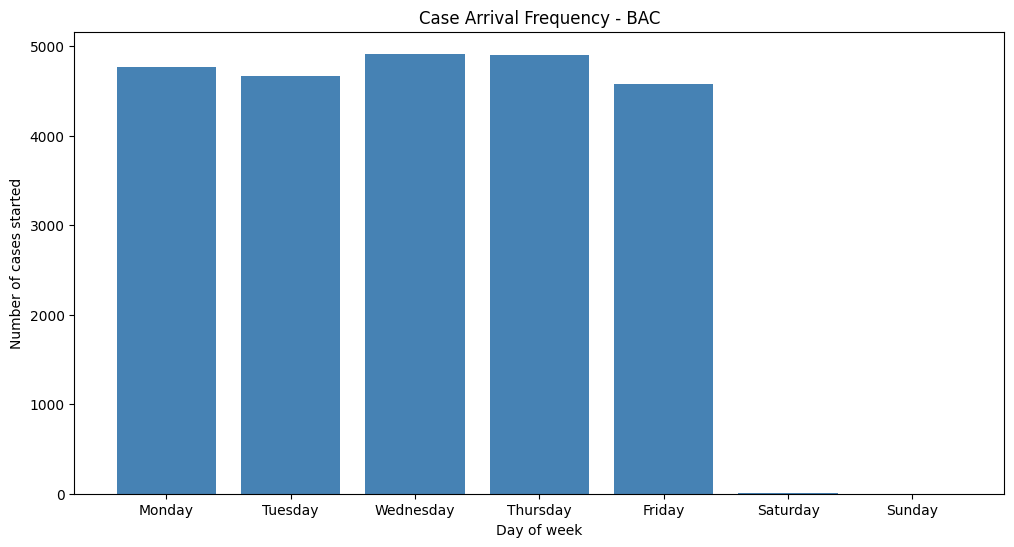

### Working-day and working-hour timetables (top 5 roles)

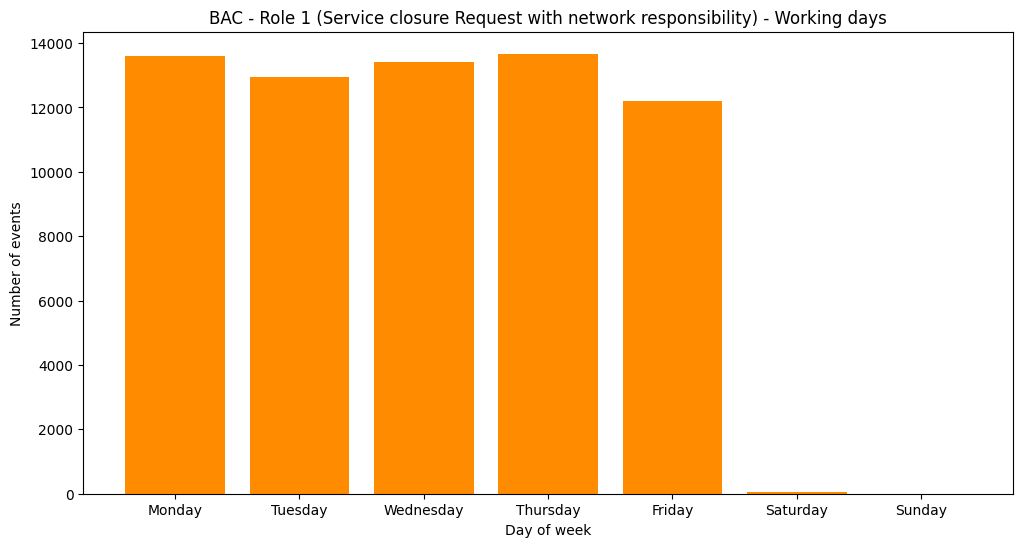

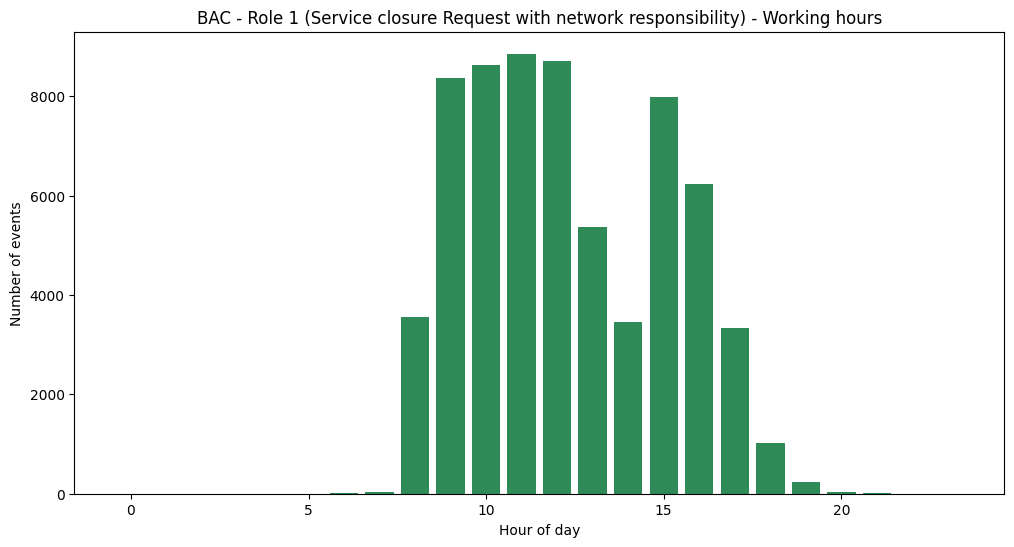

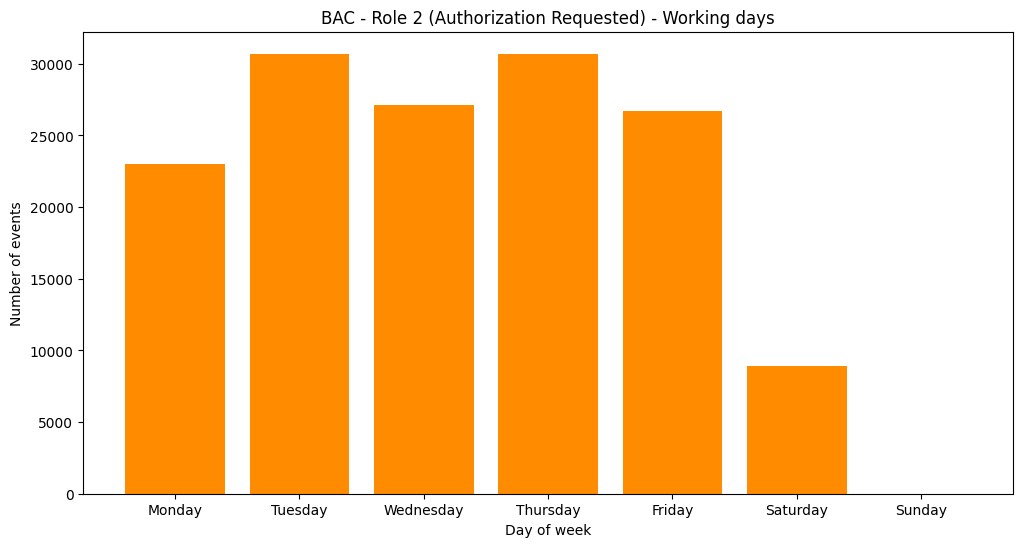

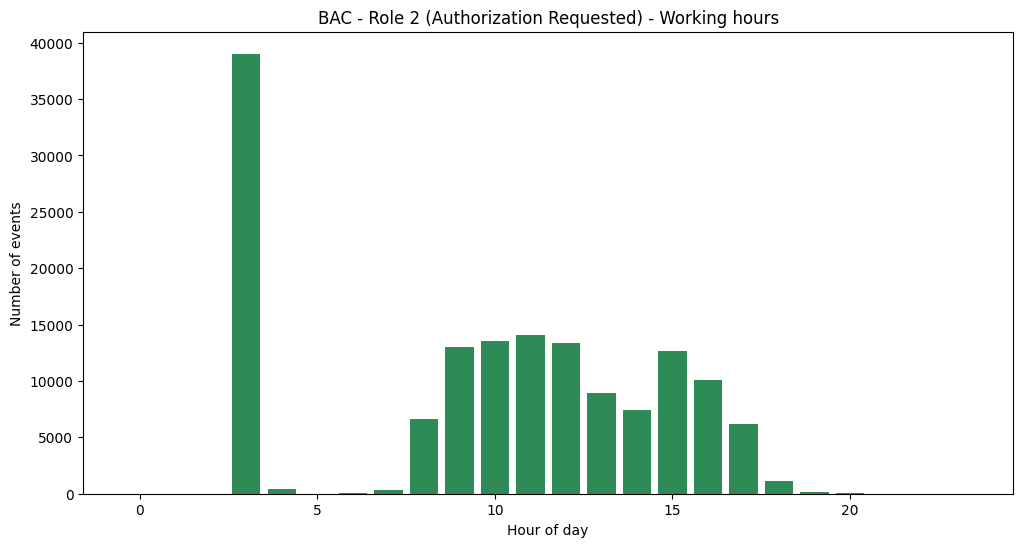

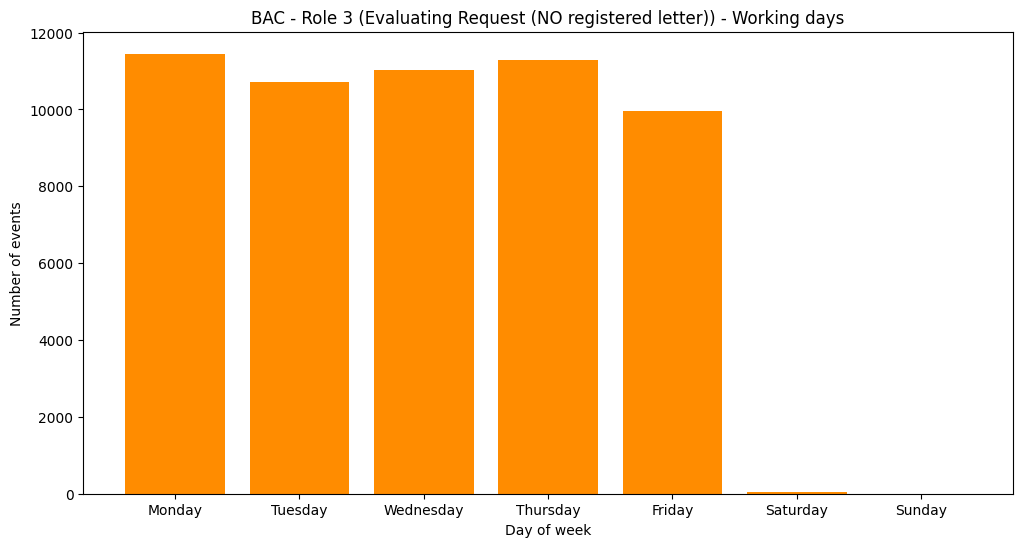

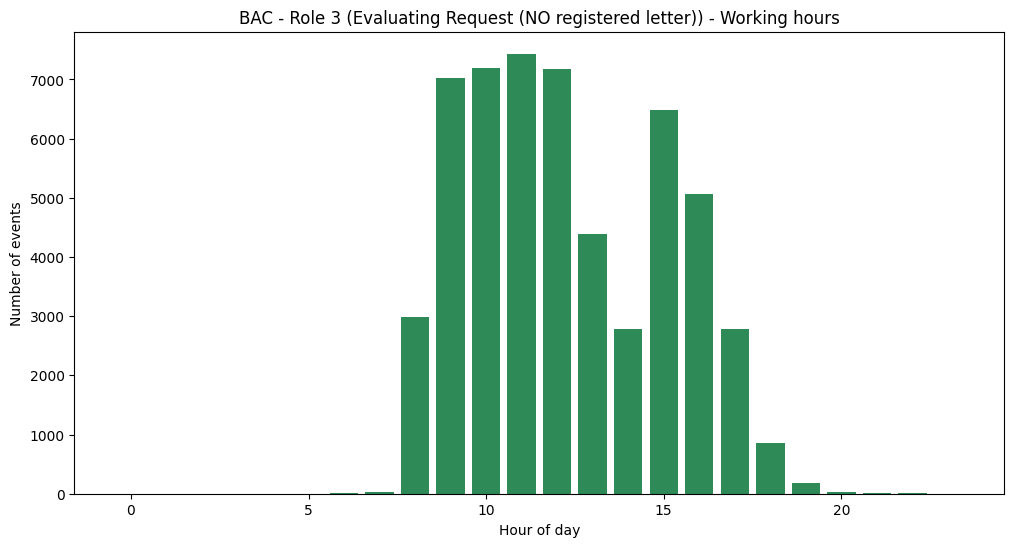

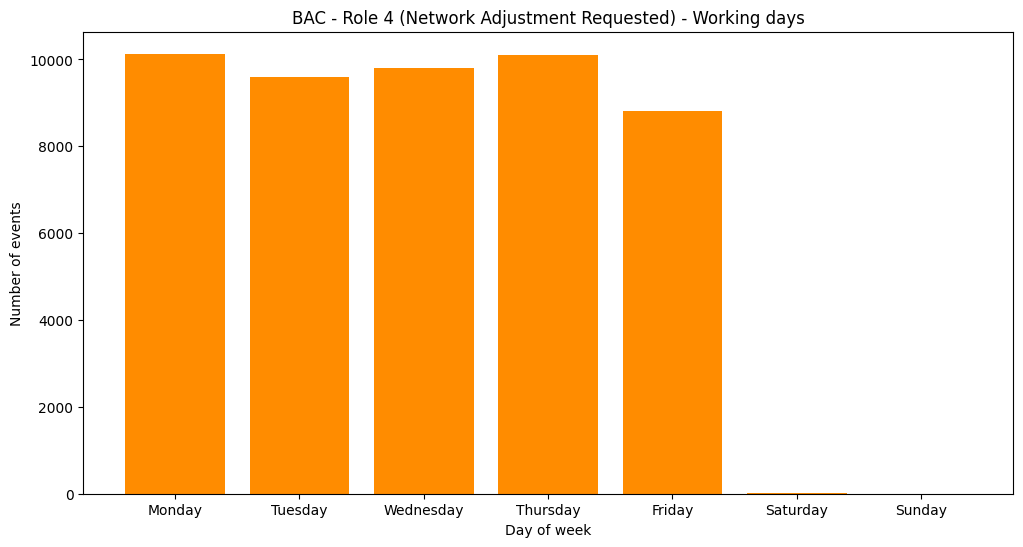

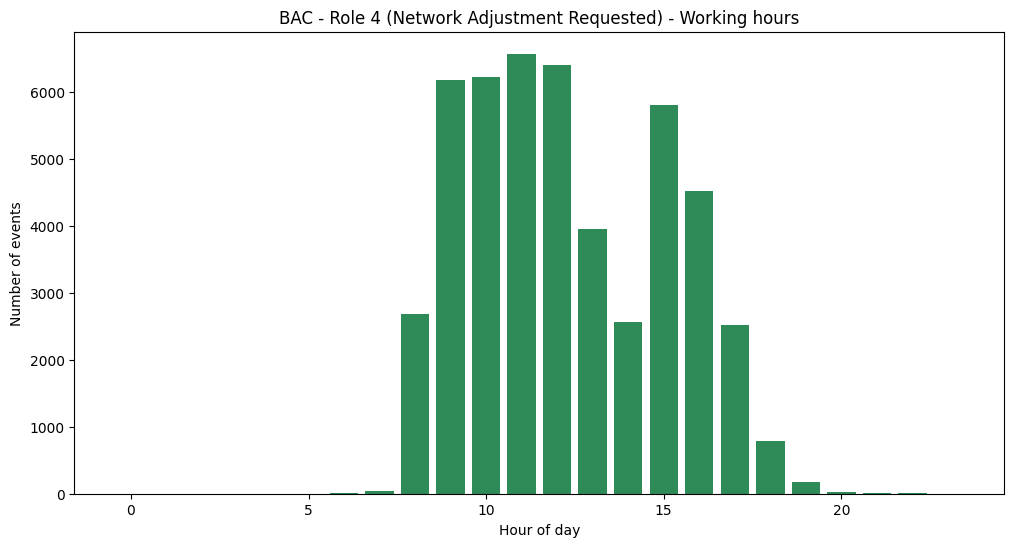

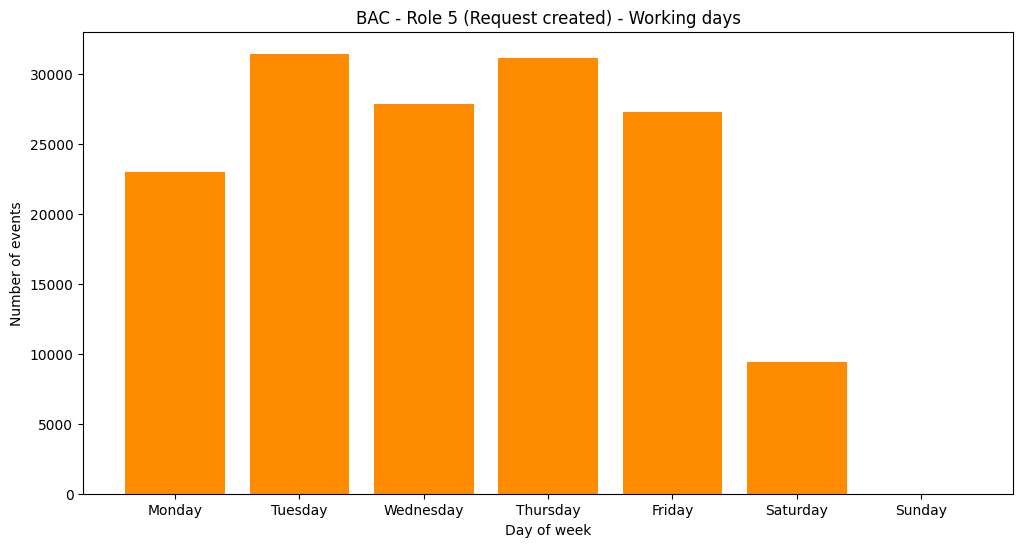

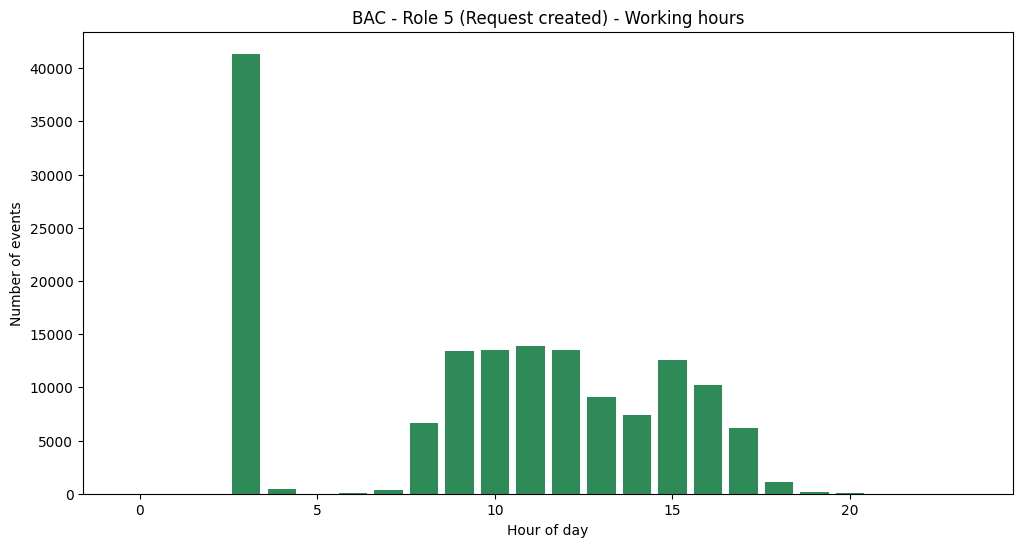

### Activity duration distributions

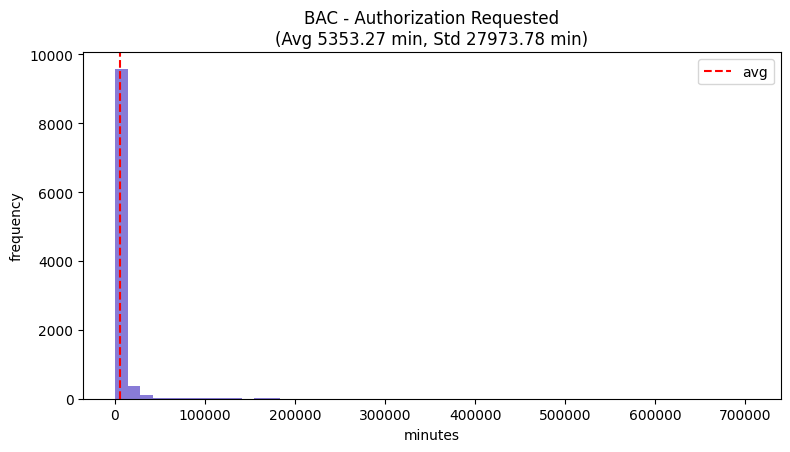

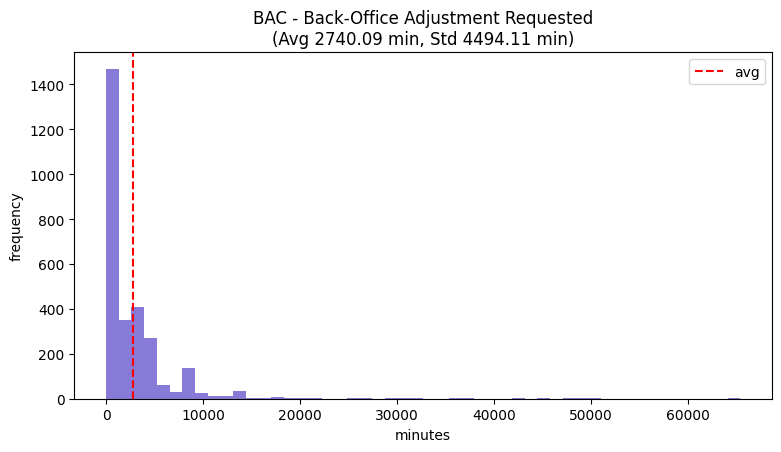

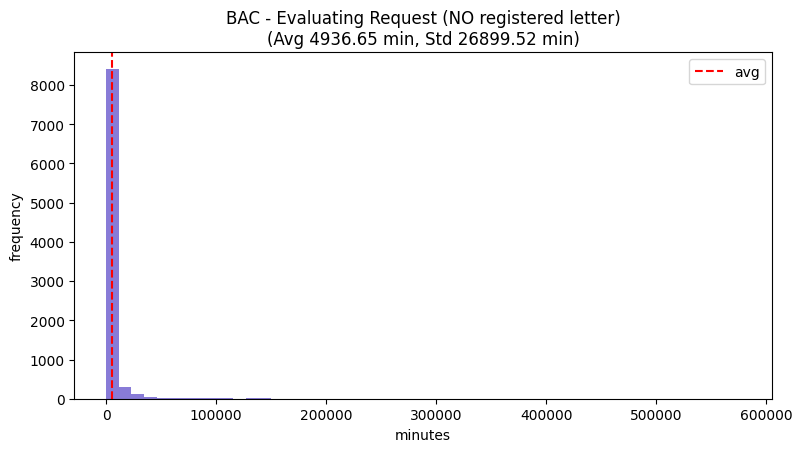

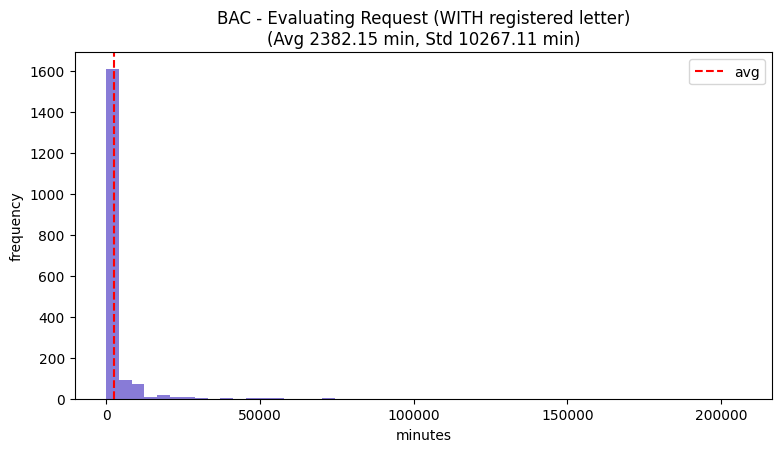

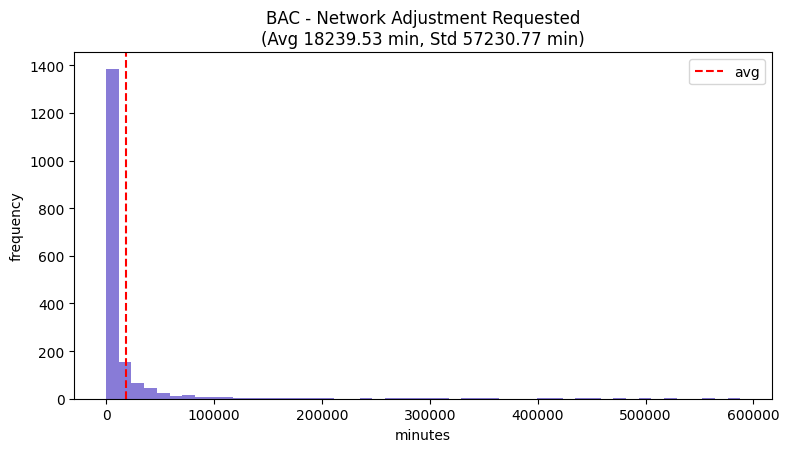

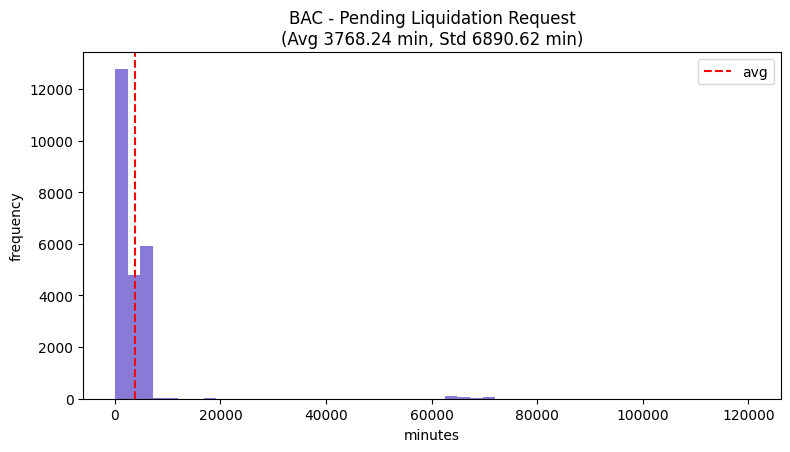

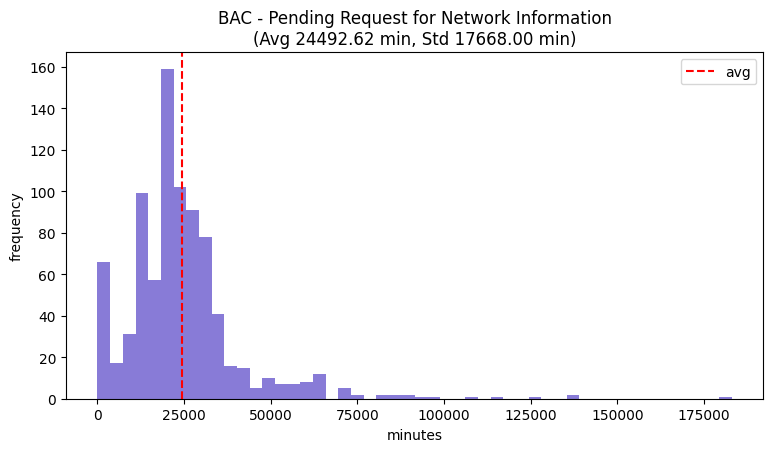

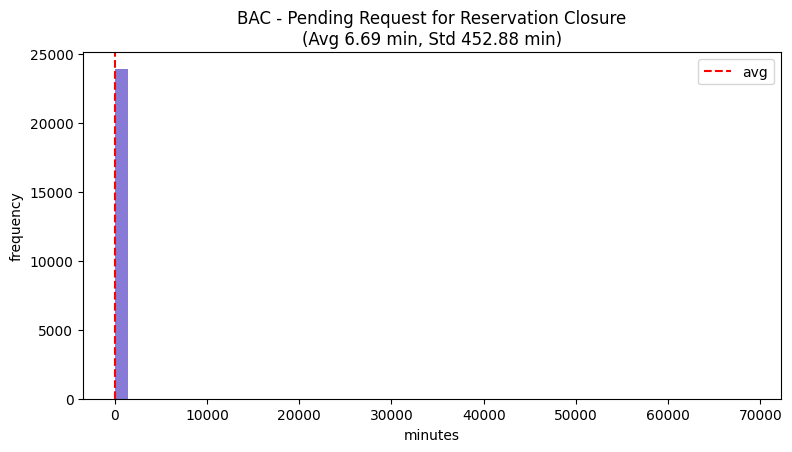

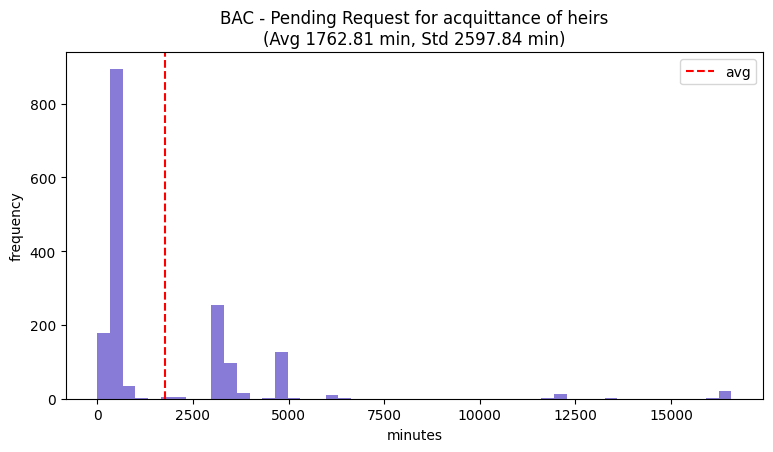

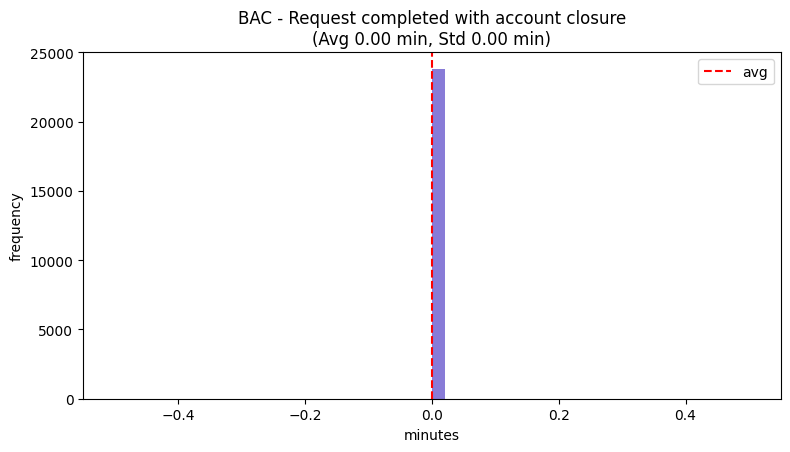

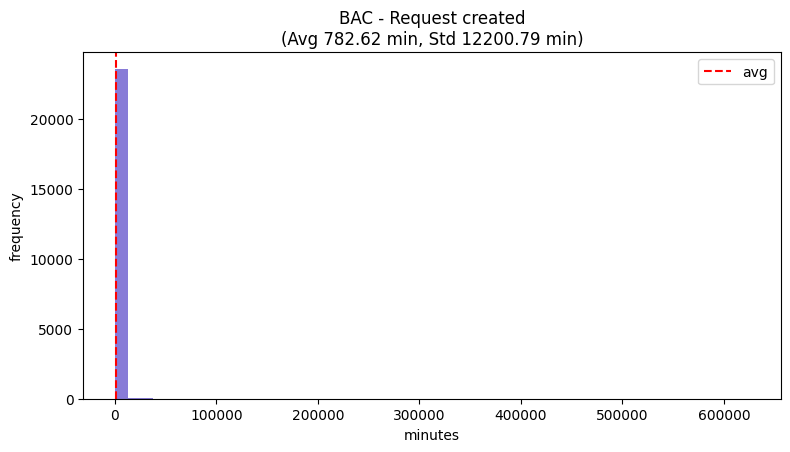

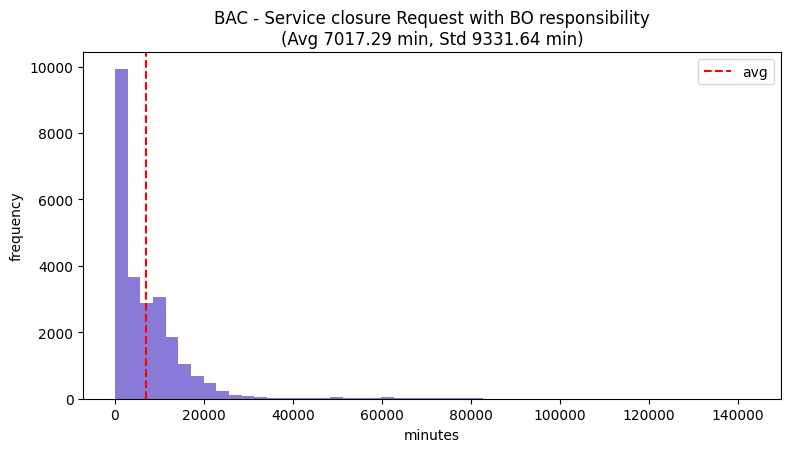

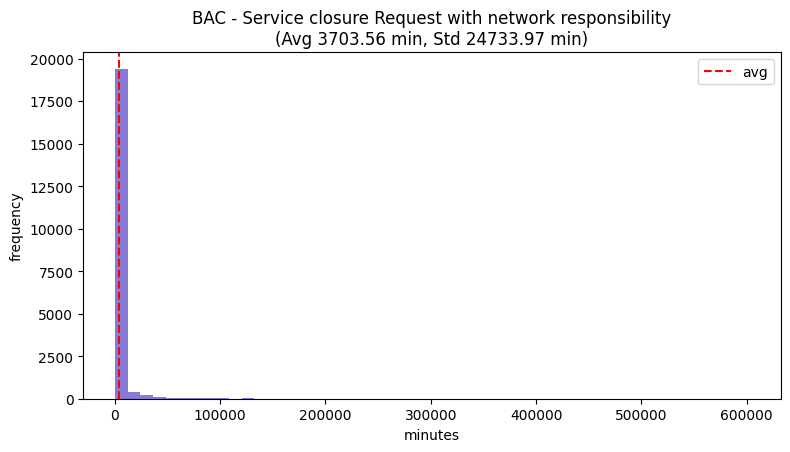

---
## Dataset: BPIC2012

### Overview

Number of cases: 3737
Number of events: 90773
Start activities: {'A_SUBMITTED': 3737}
End activities: {'W_Valideren aanvraag': 2213, 'W_Nabellen incomplete dossiers': 306, 'W_Nabellen offertes': 843, 'O_CANCELLED': 210, 'A_CANCELLED': 165}


### Resources and organizational roles

Total number of distinct resources: 61
Number of discovered organizational roles: 11

Role 1: activities = ['A_ACTIVATED', 'A_APPROVED', 'A_DECLINED', 'A_REGISTERED', 'O_ACCEPTED', 'O_DECLINED', 'W_Valideren aanvraag']
    -> 52 resource(s): [10629, 10809, 10609, 10972, 10138, 10779, 11289, 11009, 11001, 11169, 10913, 11049, 11189, 11111, 10859, 10881, 10929, 11201, 10889, 10861, 10932, 11029, 10909, 10912, 10910, 10862, 10982, 11181, 11259, 10931, 11003, 10914, 11119, 11200, 11121, 11202, 11019, 11000, 11002, 10863, 10228, 11180, 0, 10899, 10789, 10939, 11079, 11122, 10821, 10125, 10935, 11179]

Role 2: activities = ['A_ACCEPTED', 'A_FINALIZED', 'O_CREATED', 'O_SELECTED', 'O_SENT']
    -> 51 resource(s): [10862, 11201, 10912, 10939, 11203, 11000, 11111, 11119, 11019, 11122, 11202, 11120, 11001, 11180, 10909, 10889, 10982, 11169, 10971, 10913, 11200, 11189, 10809, 10880, 10863, 10629, 11179, 10859, 11121, 10609, 11009, 11181, 11002, 10881, 10861, 10228, 10933, 10914, 10138, 10779, 1097

### Case arrival frequency

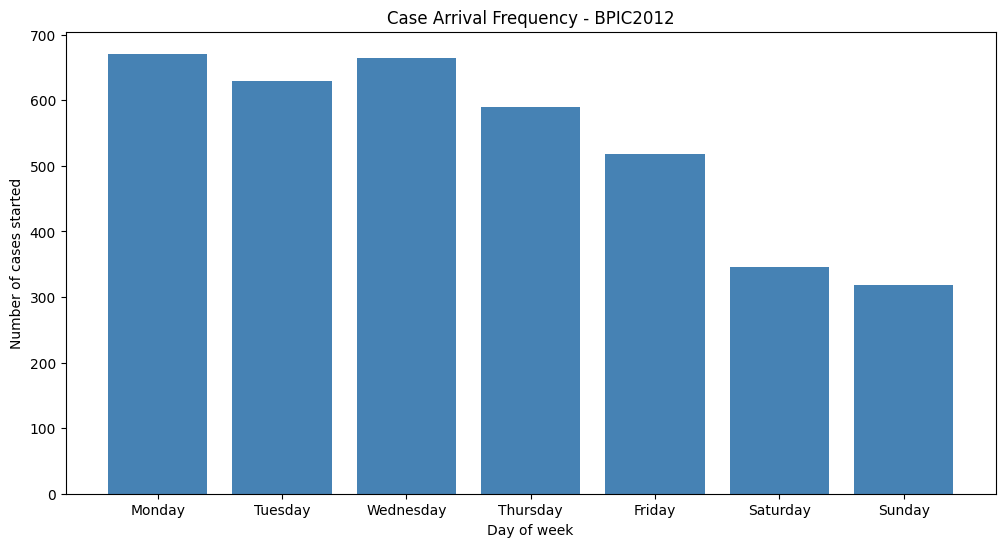

### Working-day and working-hour timetables (top 5 roles)

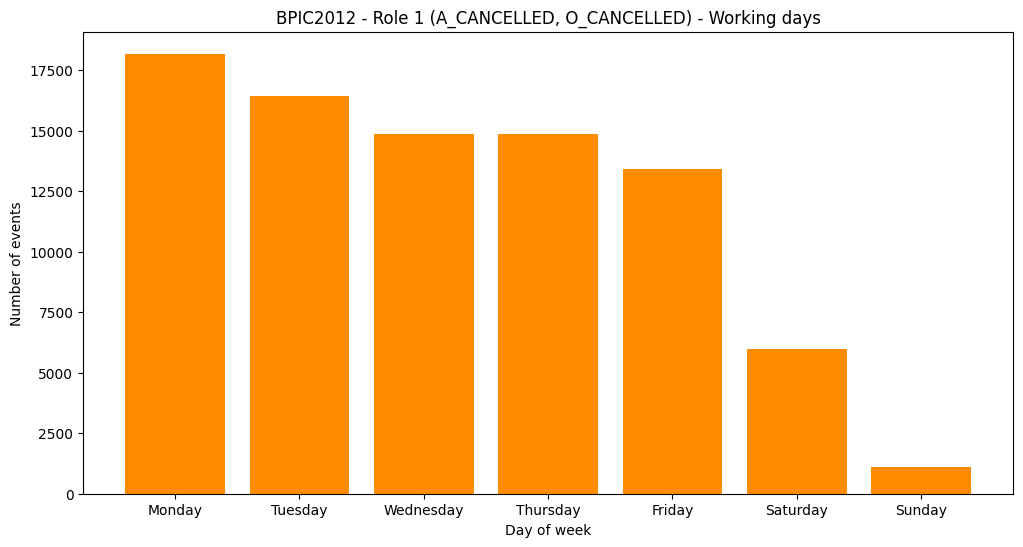

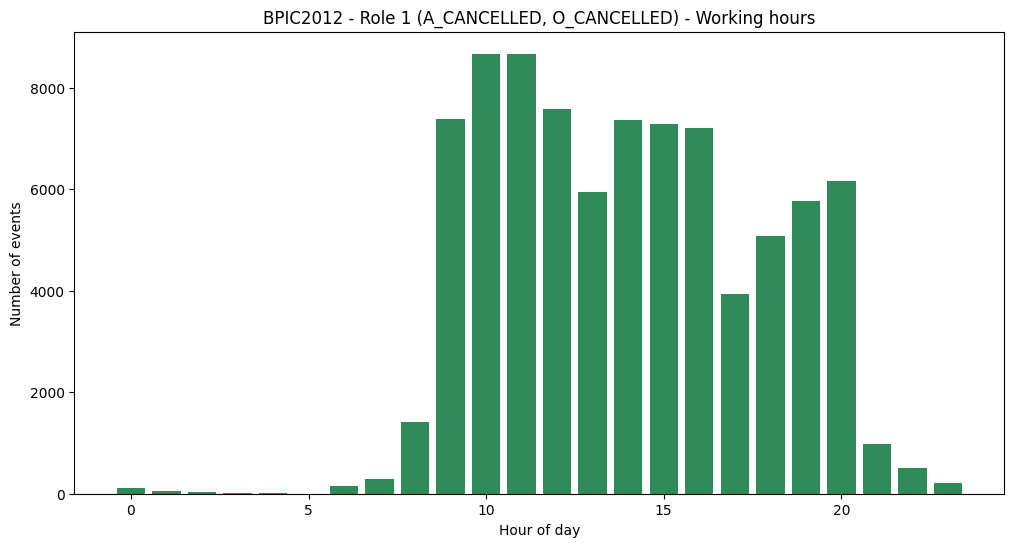

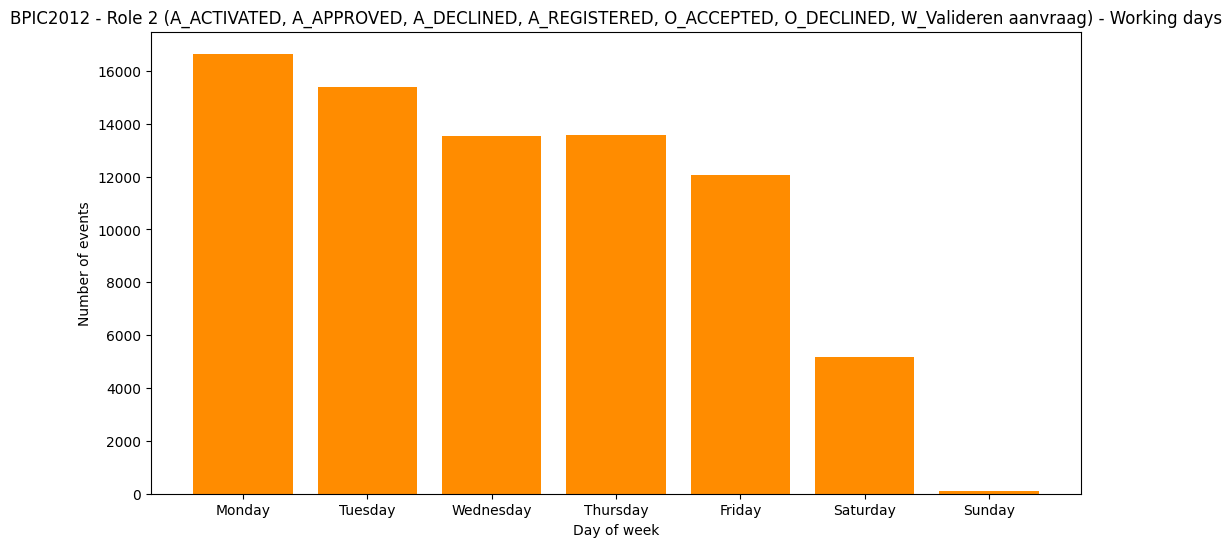

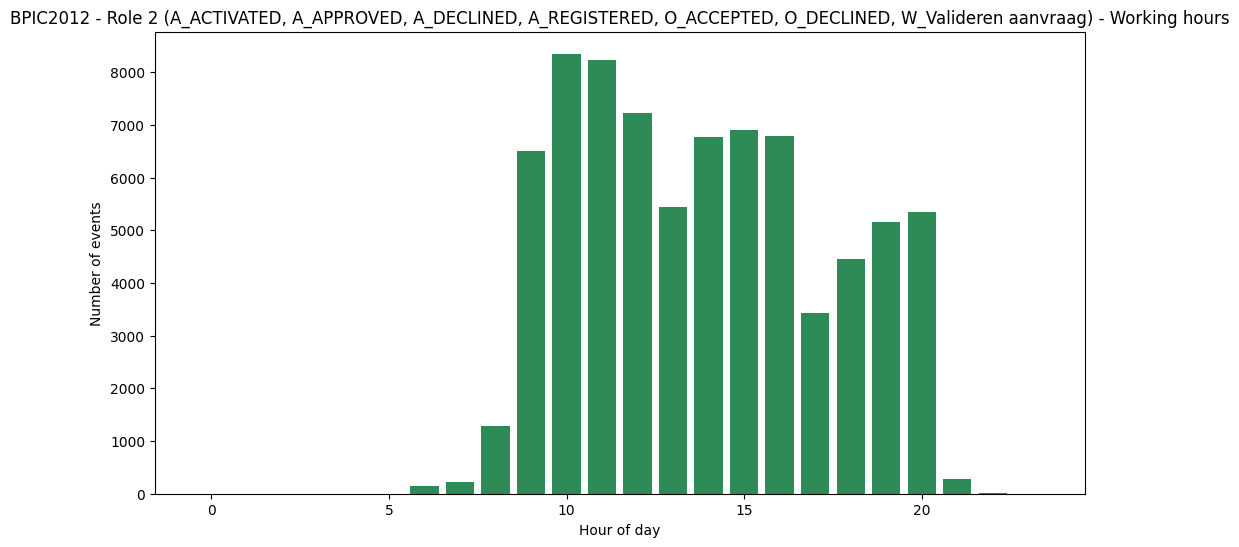

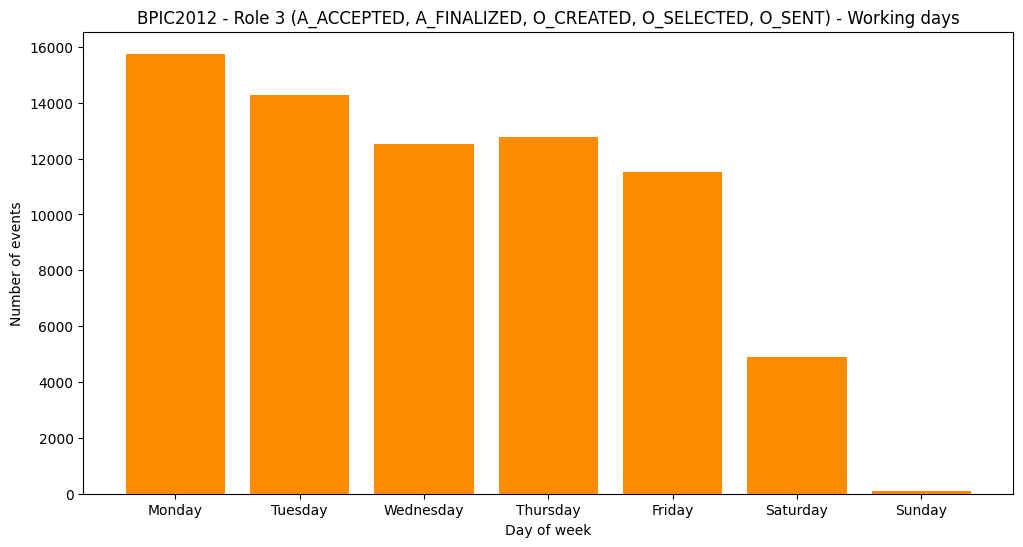

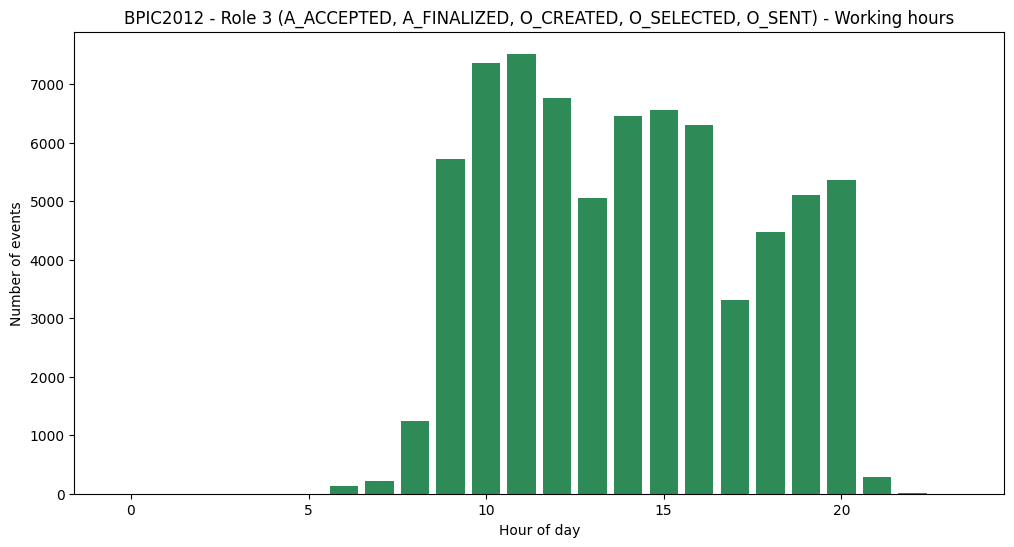

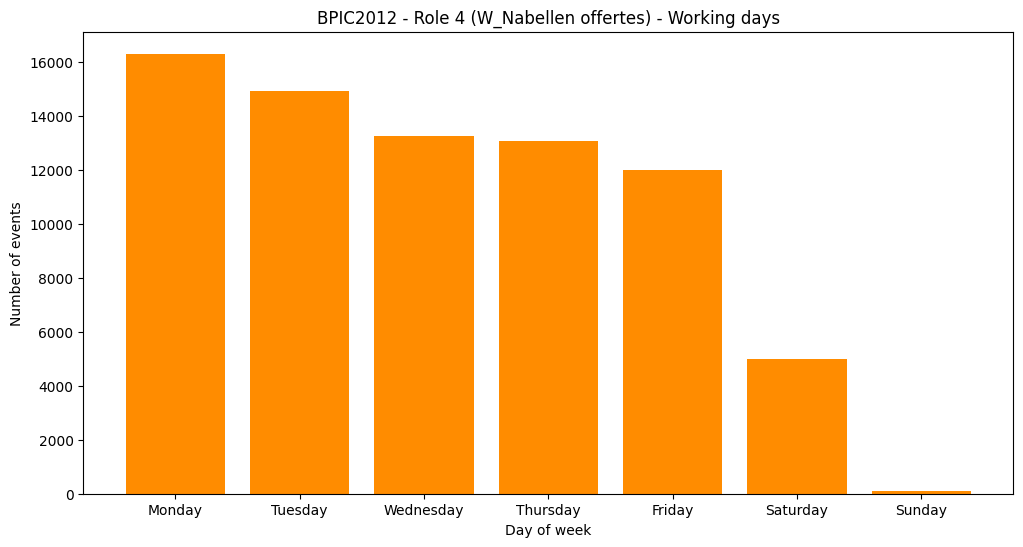

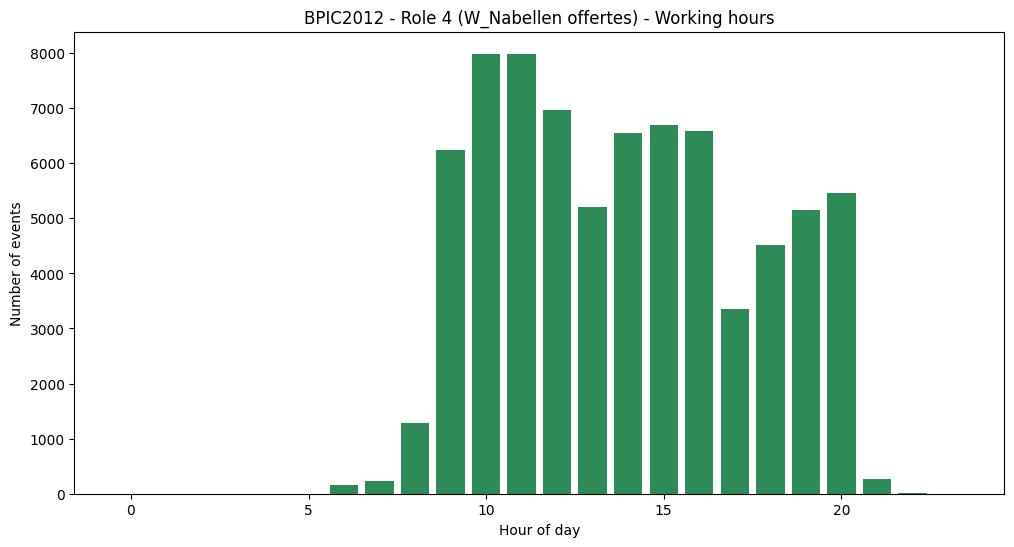

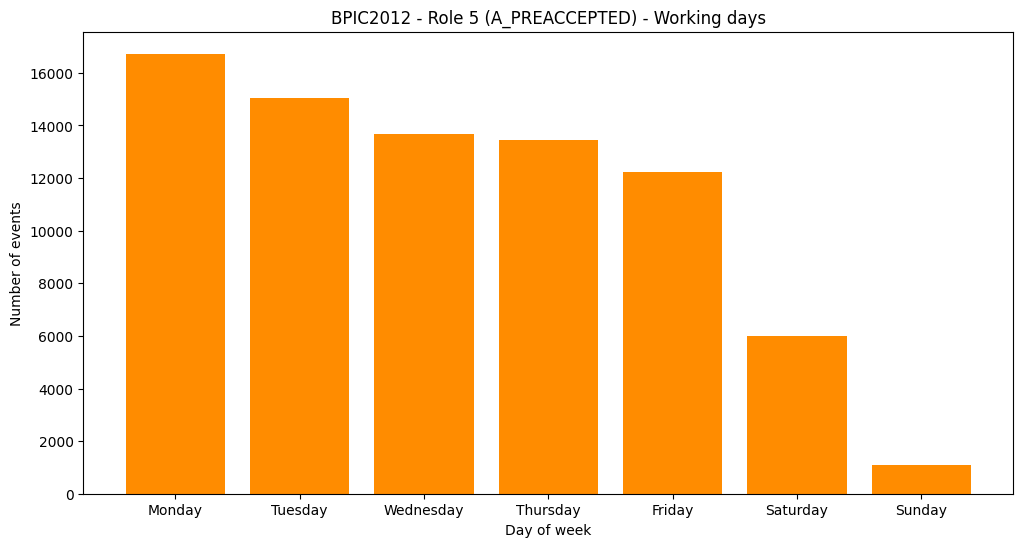

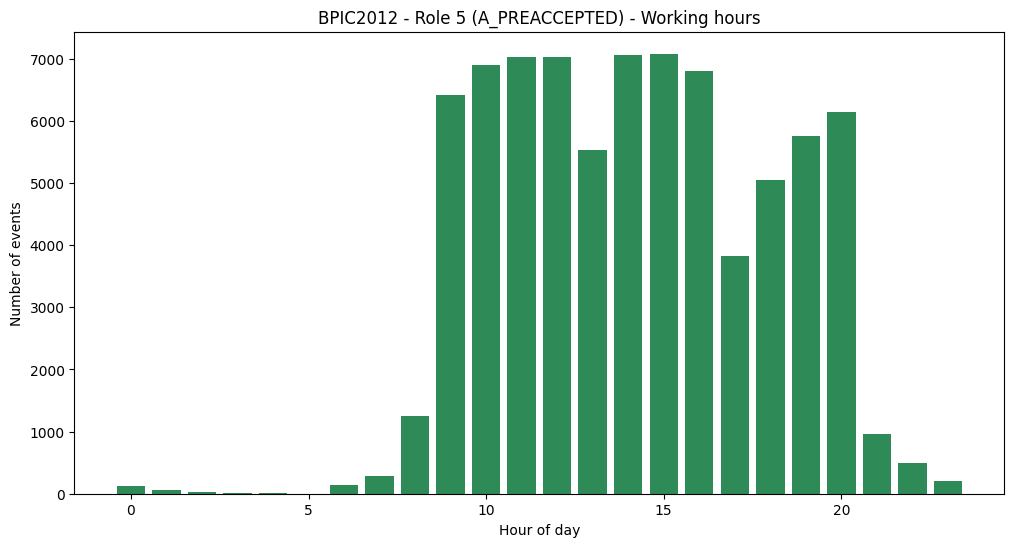

### Activity duration distributions

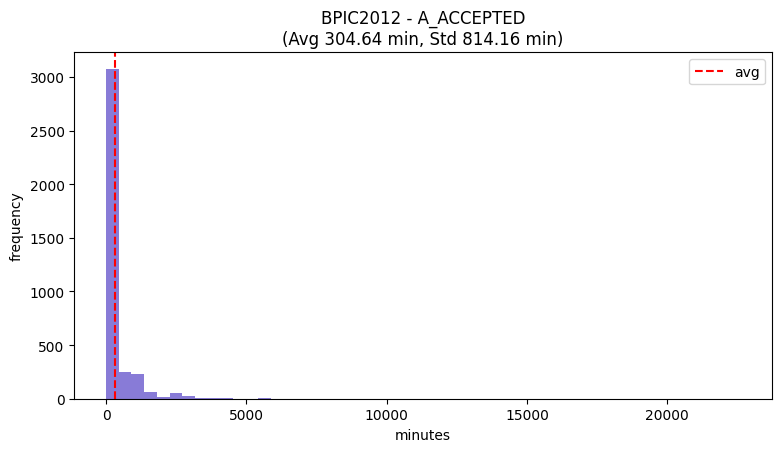

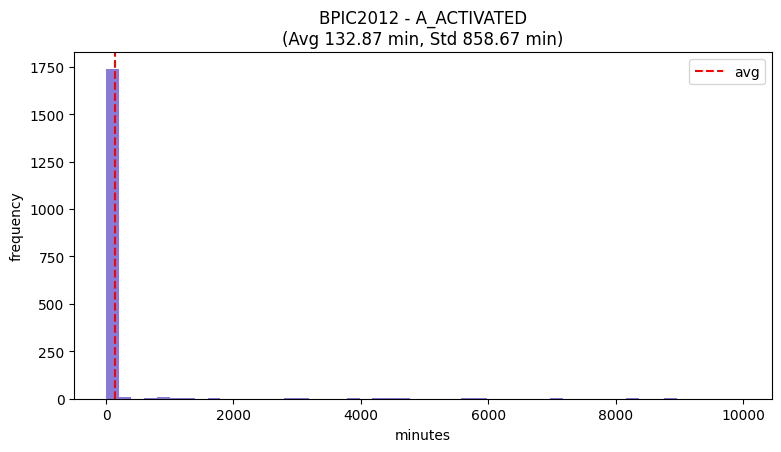

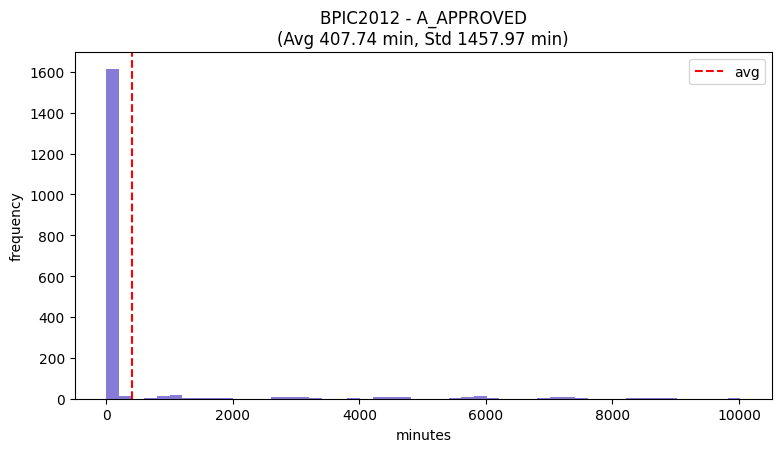

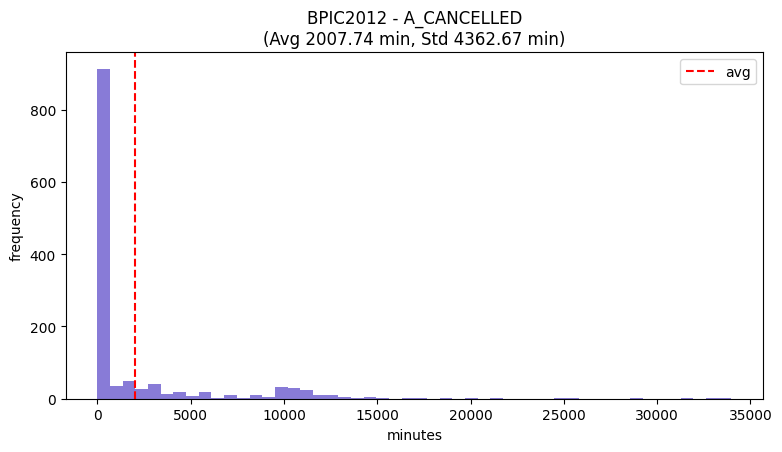

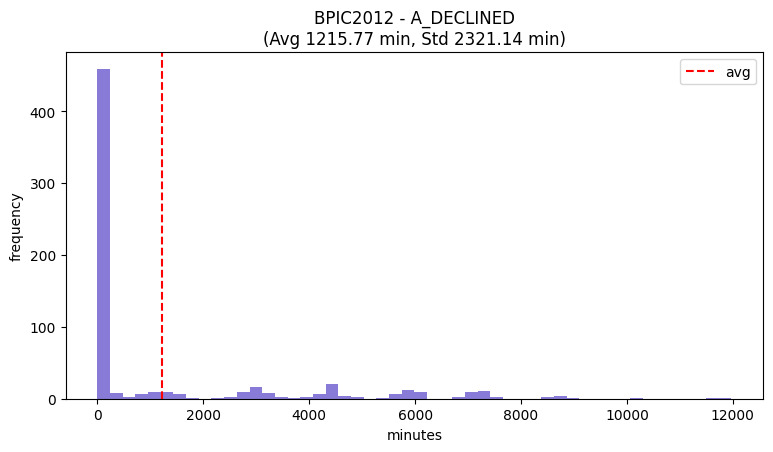

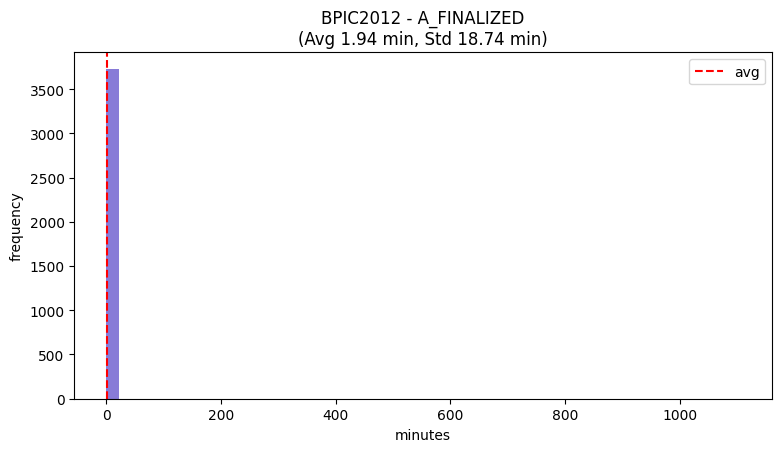

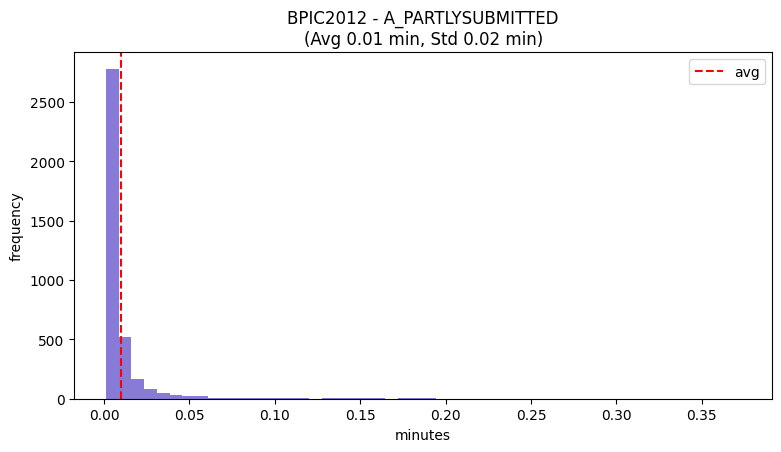

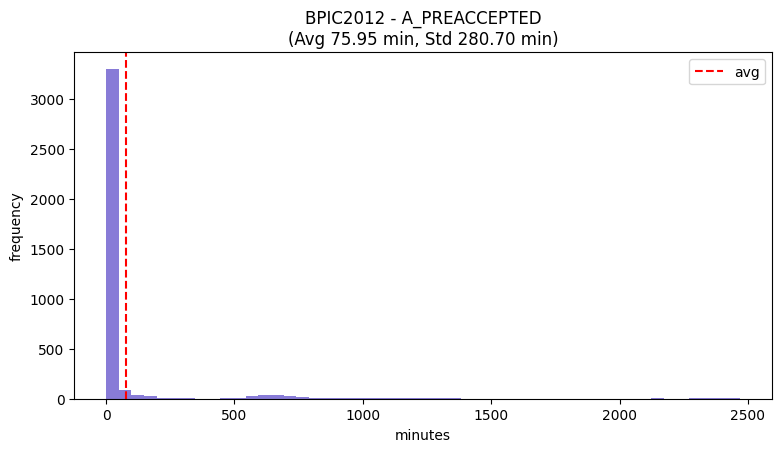

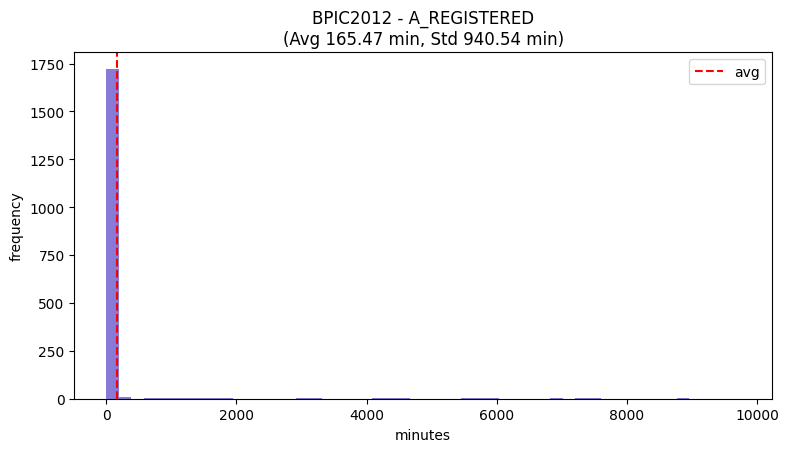

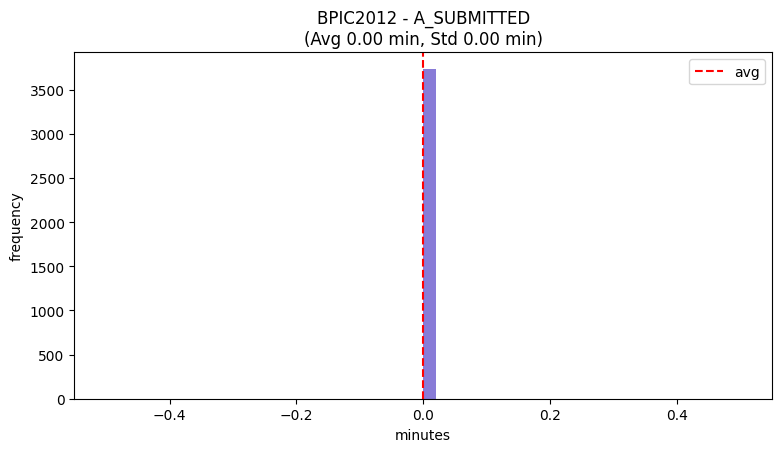

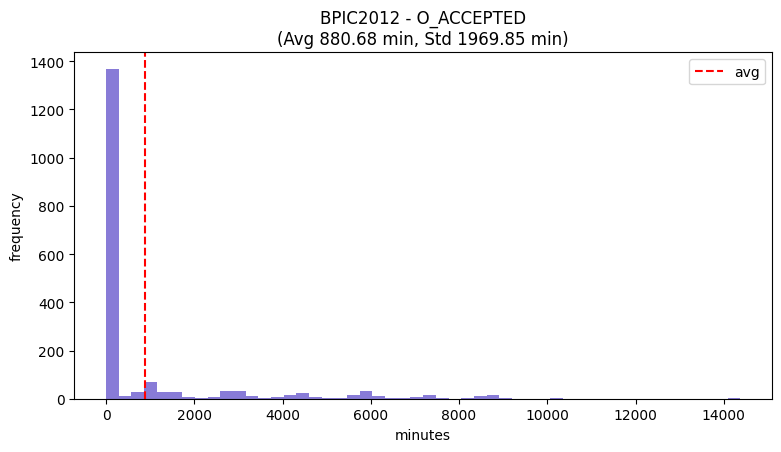

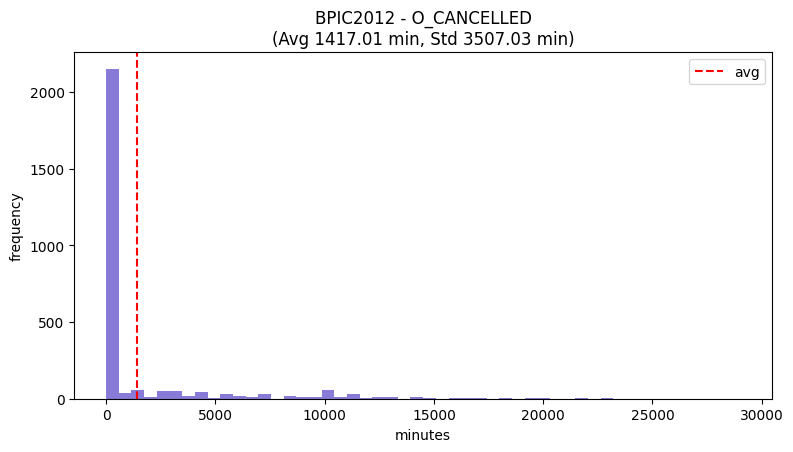

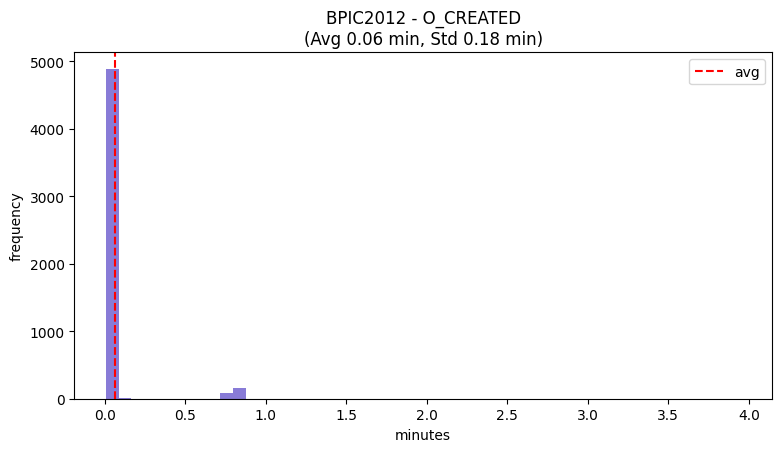

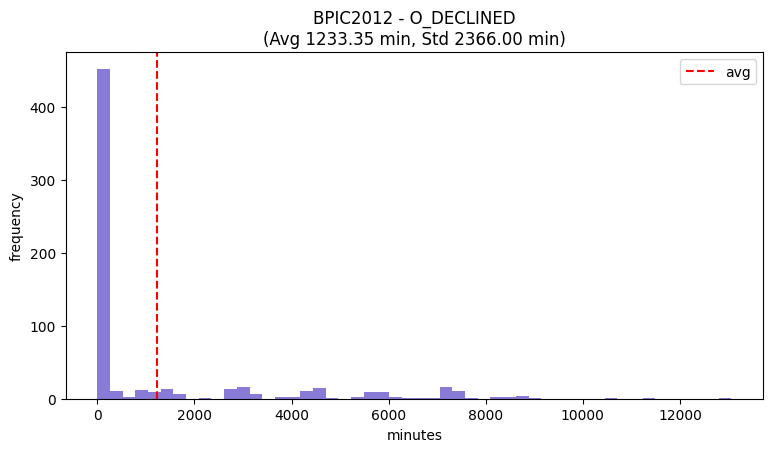

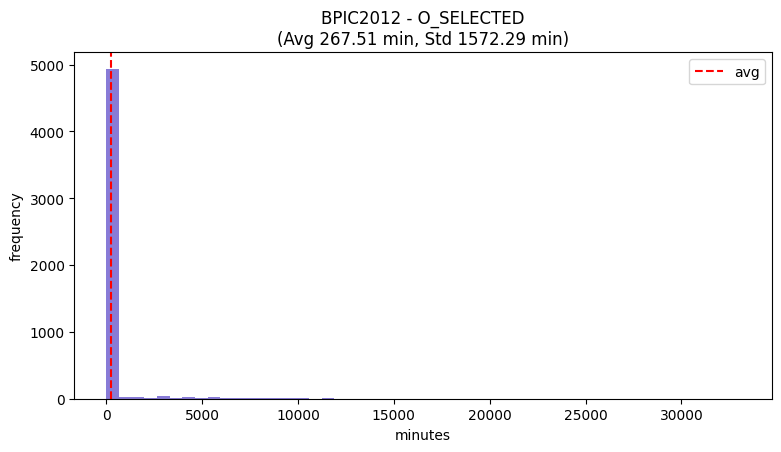

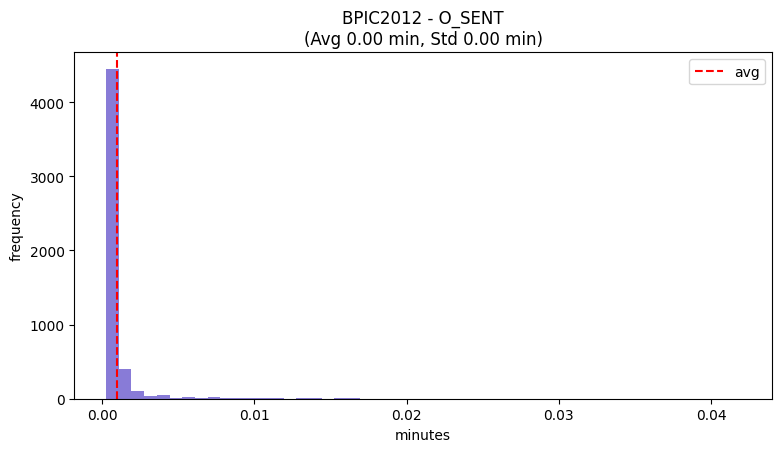

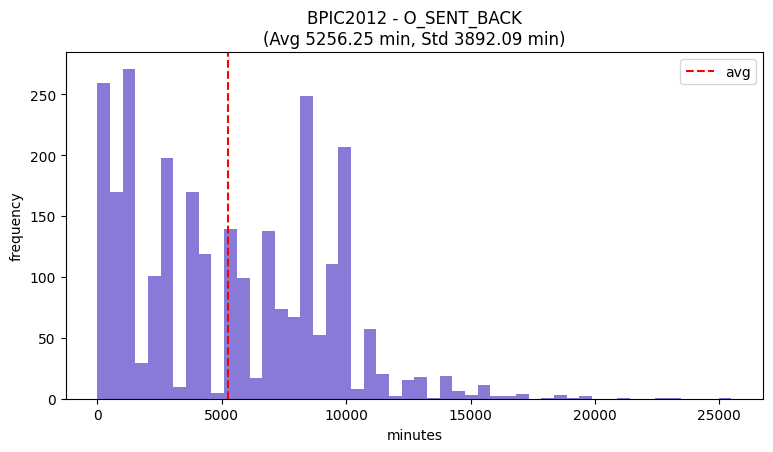

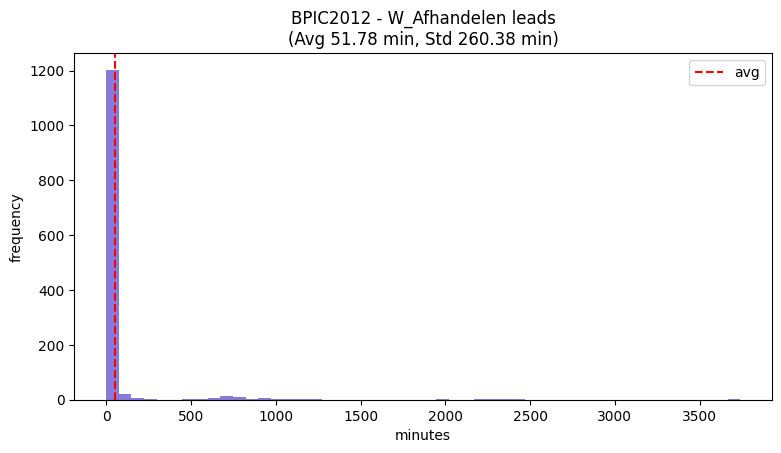

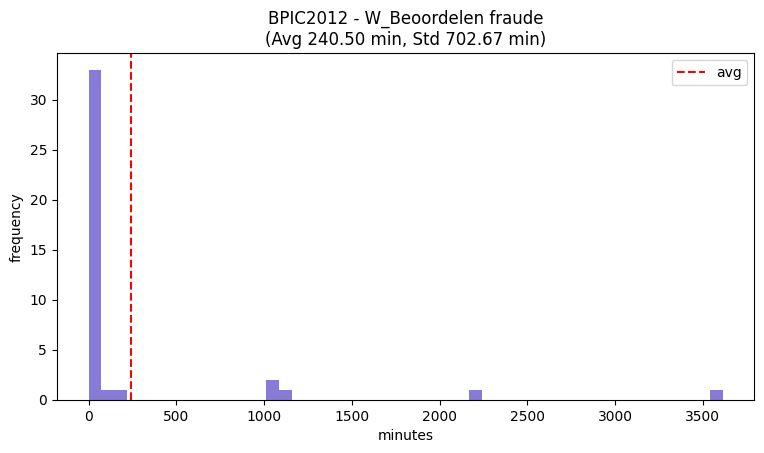

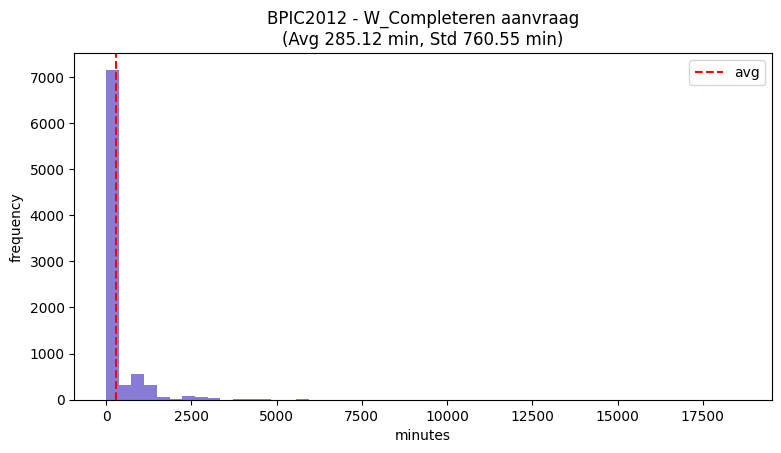

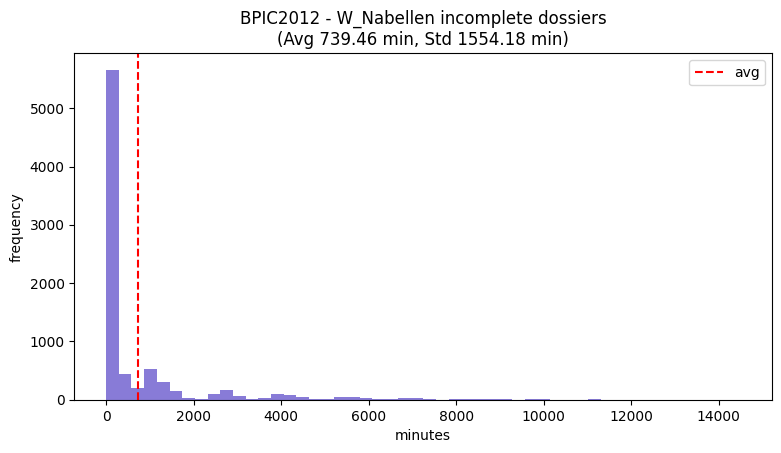

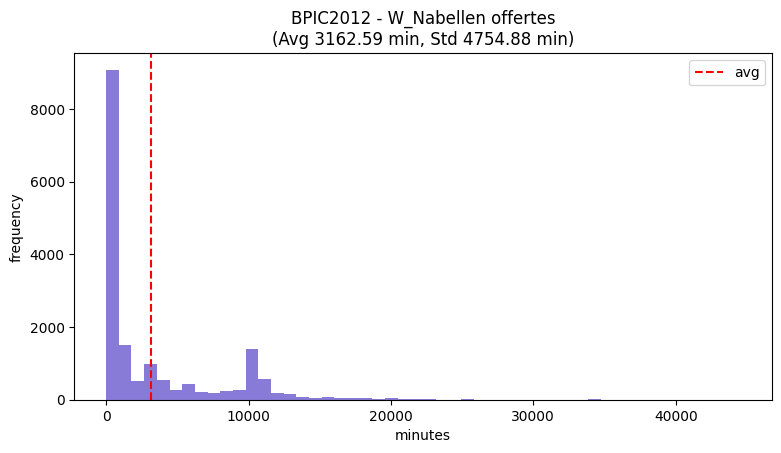

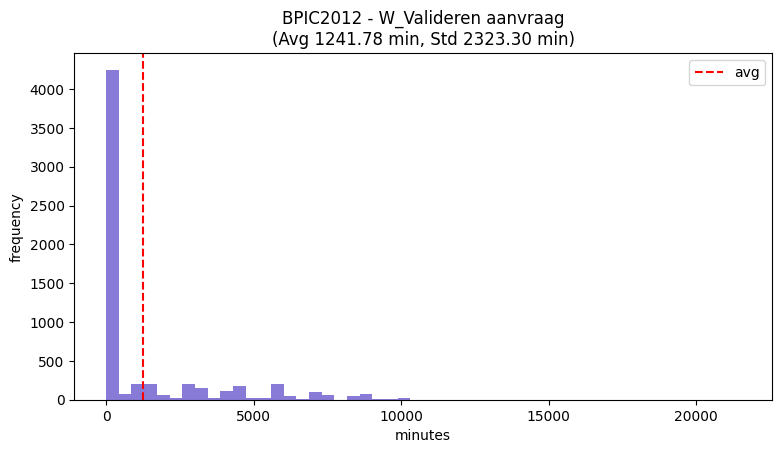

---
## Dataset: BPIC2017_Before

### Overview

Number of cases: 9763
Number of events: 146737
Start activities: {'A_Create Application': 9763}
End activities: {'O_Cancelled': 4143, 'A_Pending': 2887, 'W_Validate application': 2087, 'O_Refused': 335, 'W_Call incomplete files': 185, 'W_Call after offers': 39, 'A_Denied': 5, 'A_Cancelled': 41, 'W_Assess potential fraud': 23, 'W_Complete application': 18}


### Resources and organizational roles

Total number of distinct resources: 98
Number of discovered organizational roles: 13

Role 1: activities = ['A_Accepted', 'A_Complete', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application']
    -> 84 resource(s): ['User_71', 'User_28', 'User_37', 'User_23', 'User_42', 'User_48', 'User_27', 'User_3', 'User_41', 'User_43', 'User_24', 'User_35', 'User_49', 'User_22', 'User_51', 'User_73', 'User_10', 'User_18', 'User_21', 'User_38', 'User_39', 'User_86', 'User_34', 'User_5', 'User_17', 'User_36', 'User_44', 'User_7', 'User_32', 'User_19', 'User_95', 'User_14', 'User_13', 'User_46', 'User_16', 'User_89', 'User_97', 'User_12', 'User_25', 'User_26', 'User_52', 'User_31', 'User_60', 'User_15', 'User_11', 'User_61', 'User_53', 'User_85', 'User_9', 'User_92', 'User_47', 'User_2', 'User_4', 'User_70', 'User_74', 'User_20', 'User_33', 'User_108', 'User_8', 'User_40', 'User_76', 'User_6', 'User_75', 'User_102', 'User_110', 'User_109', 'User_29', 'User_103', 'User_99',

### Case arrival frequency

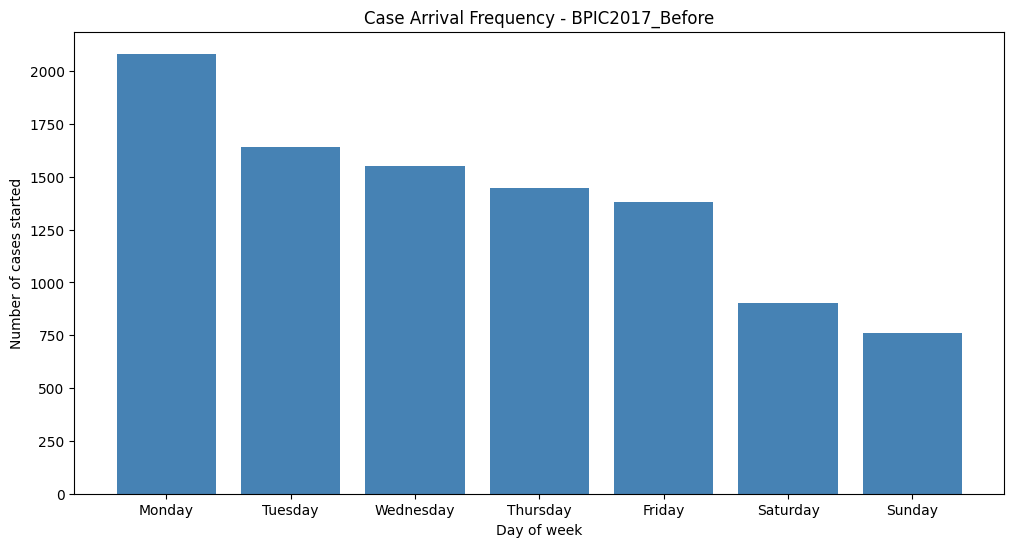

### Working-day and working-hour timetables (top 5 roles)

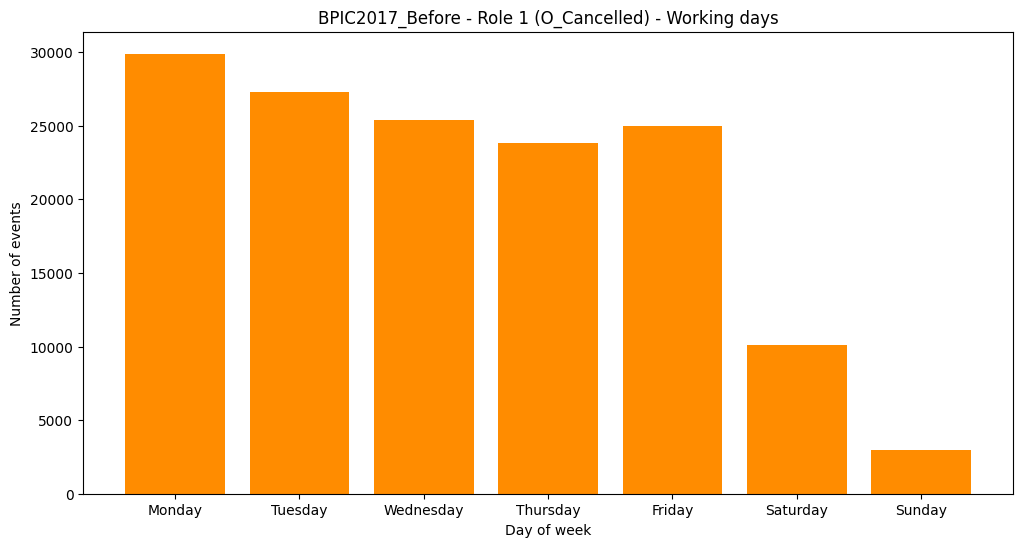

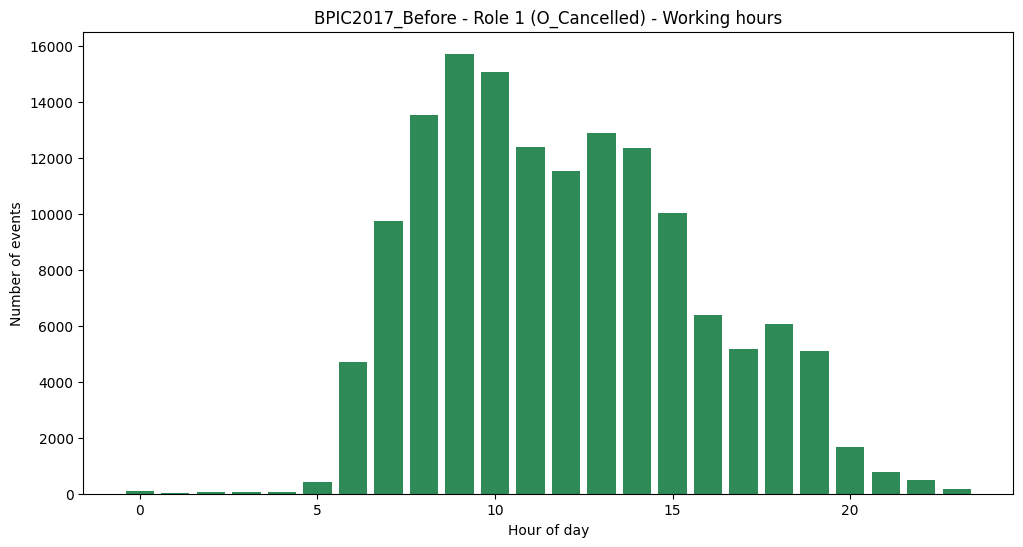

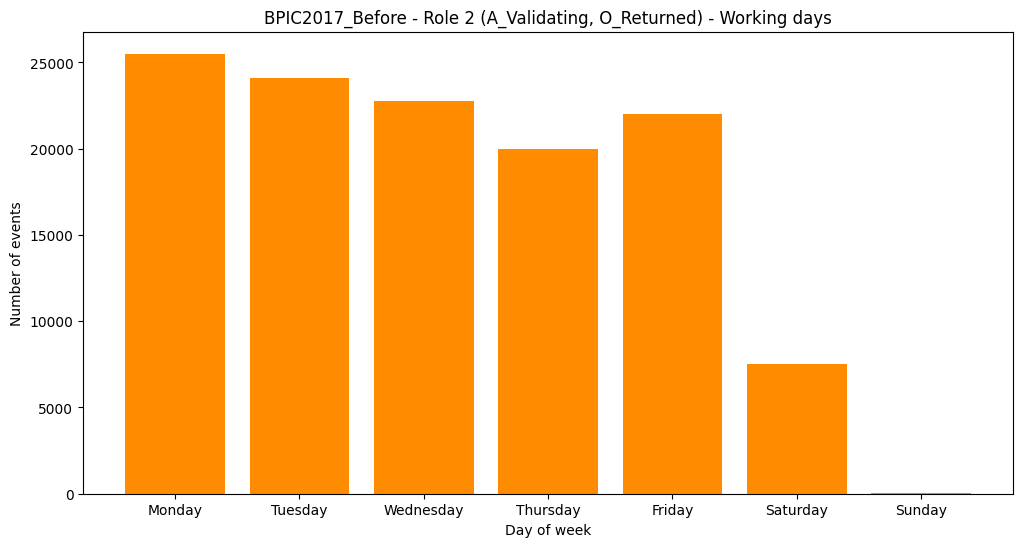

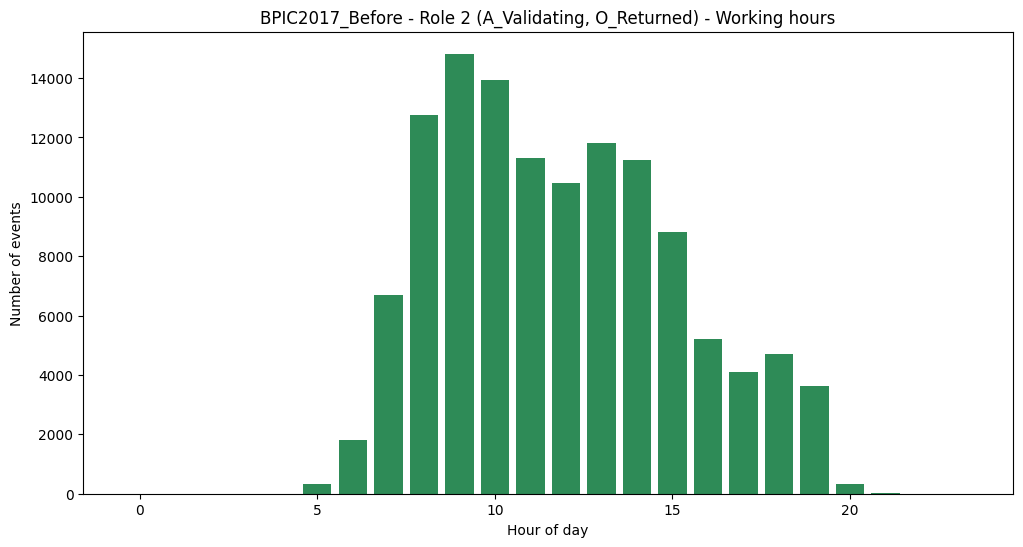

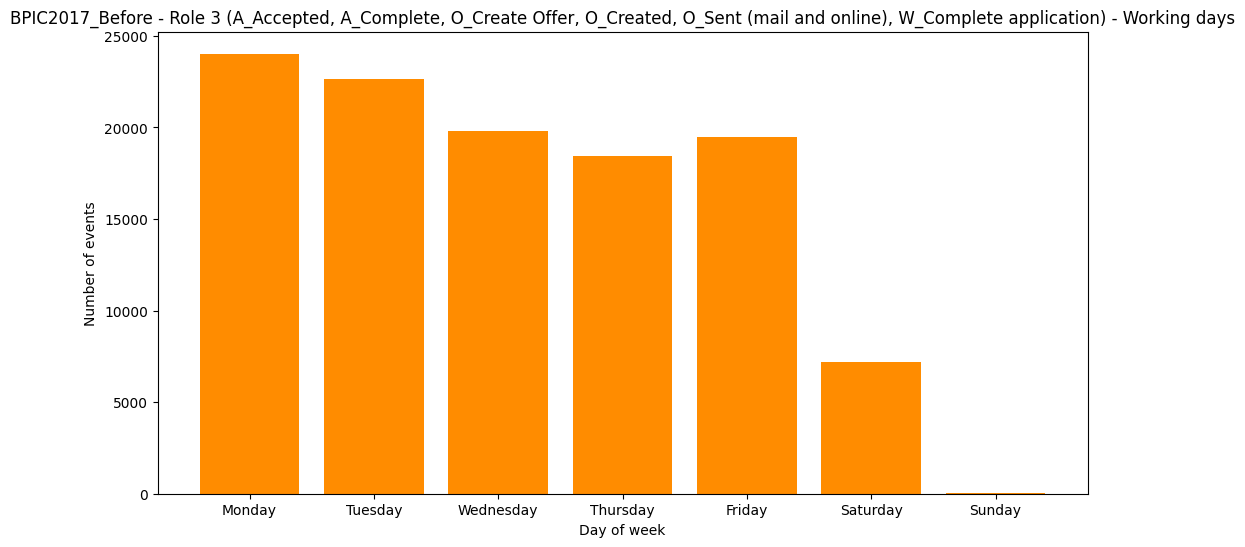

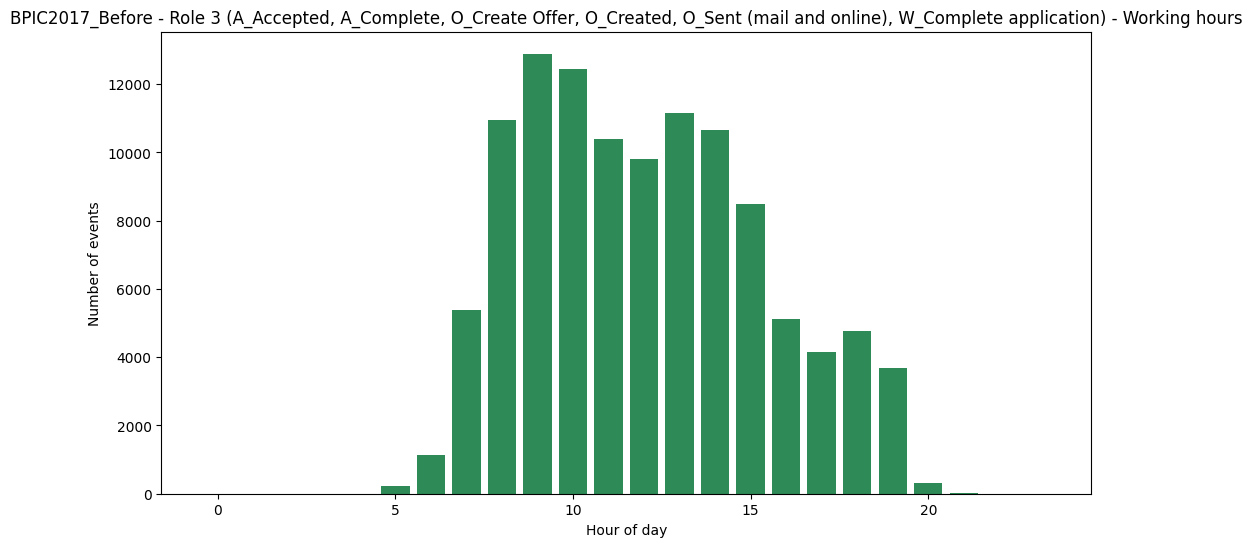

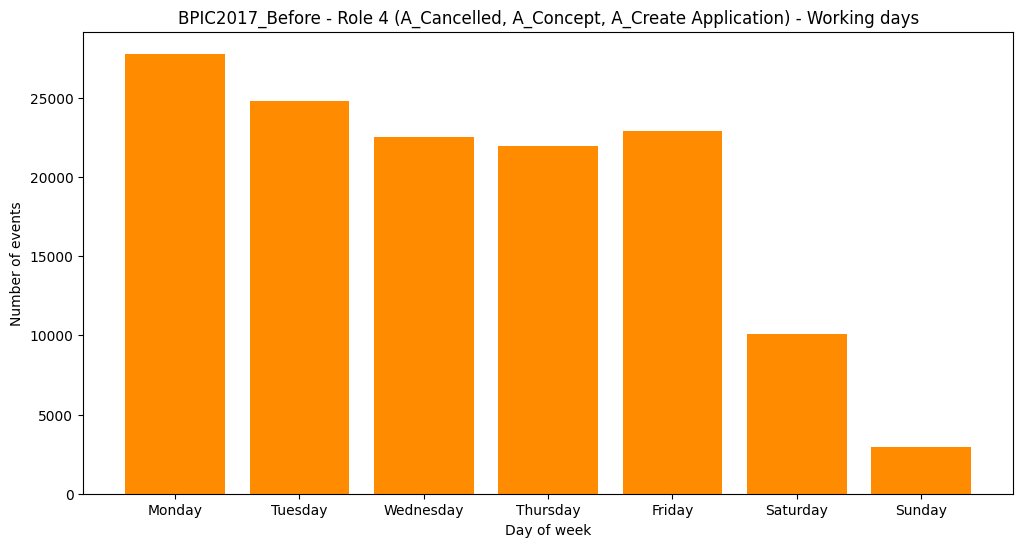

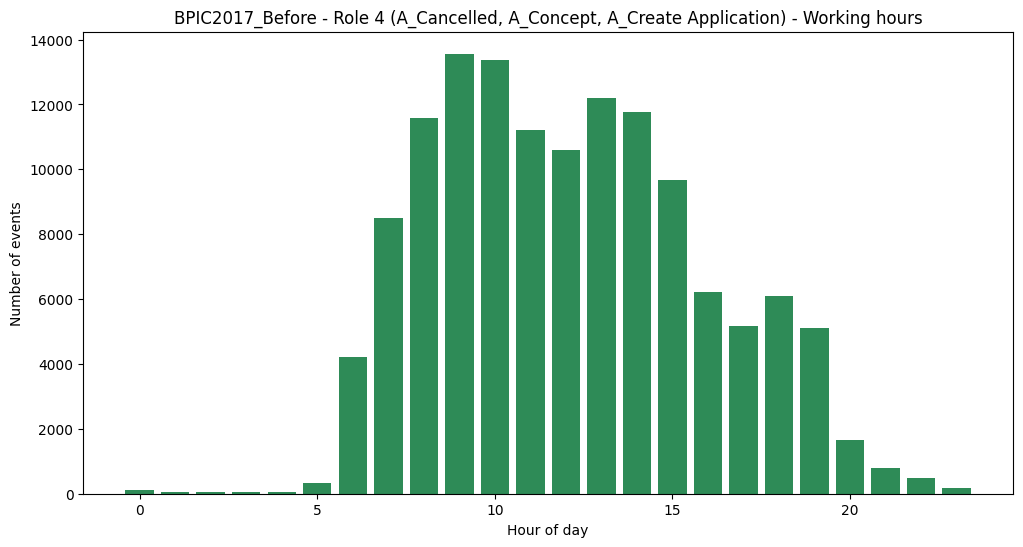

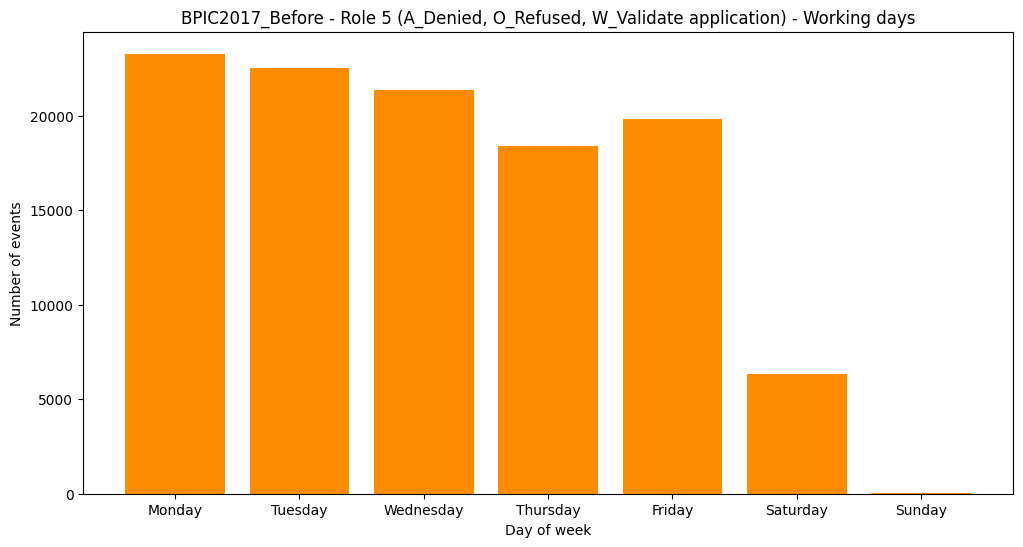

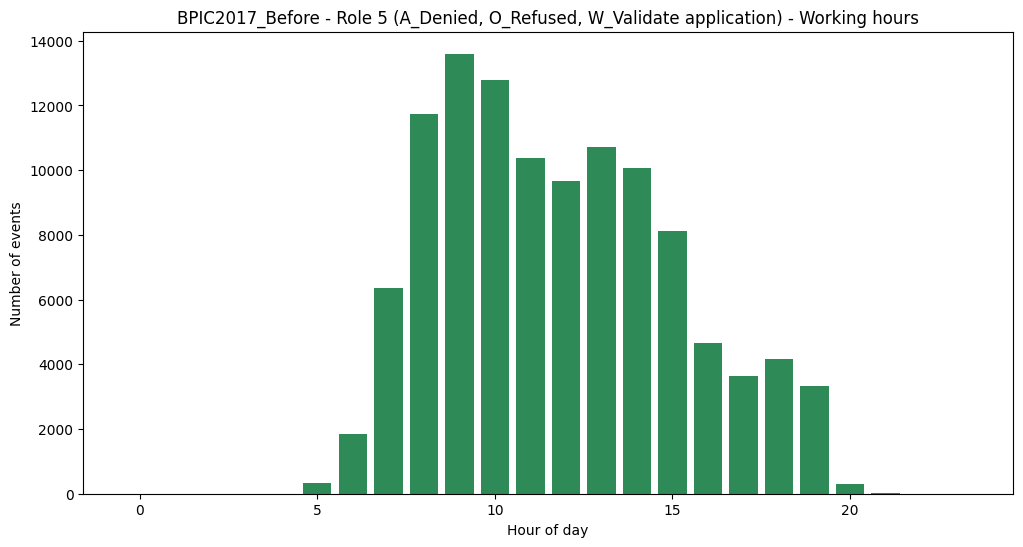

### Activity duration distributions

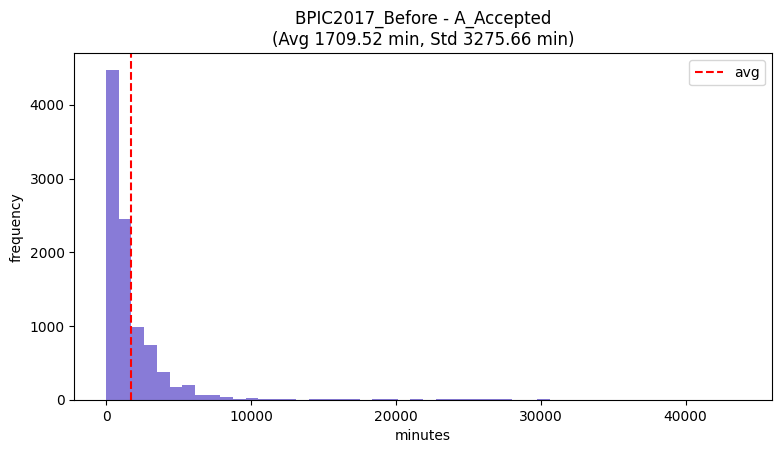

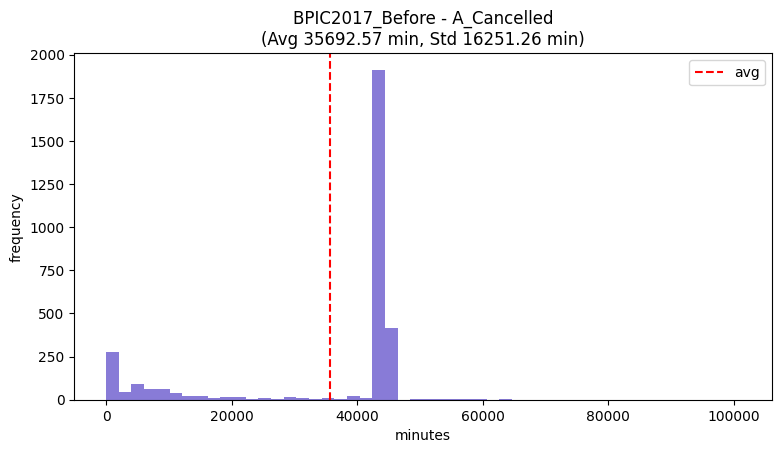

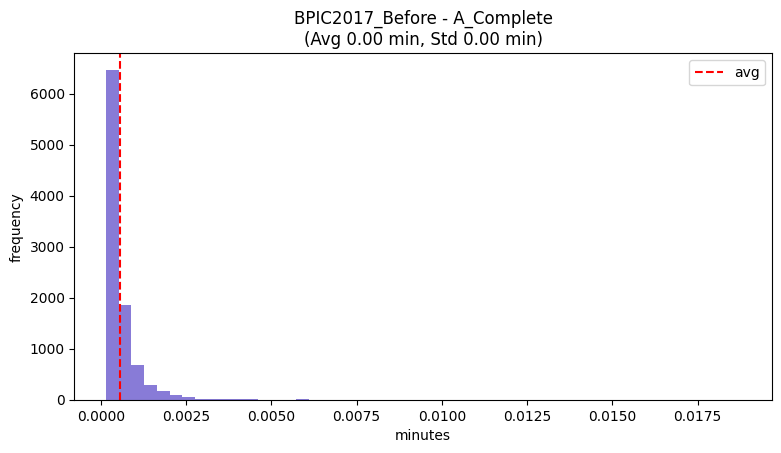

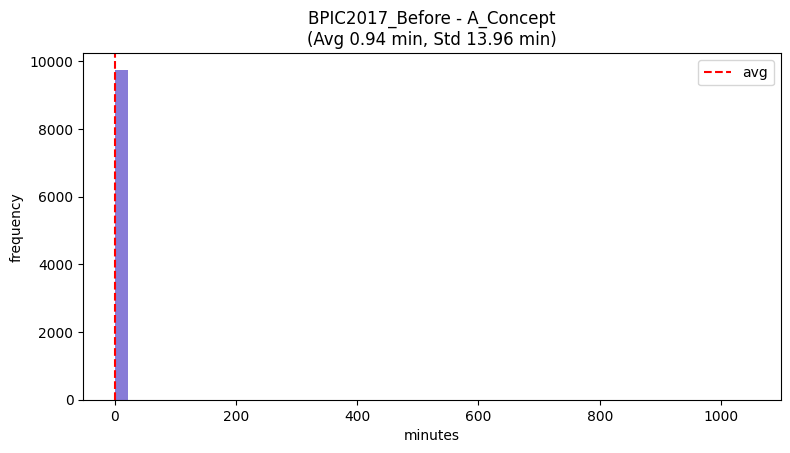

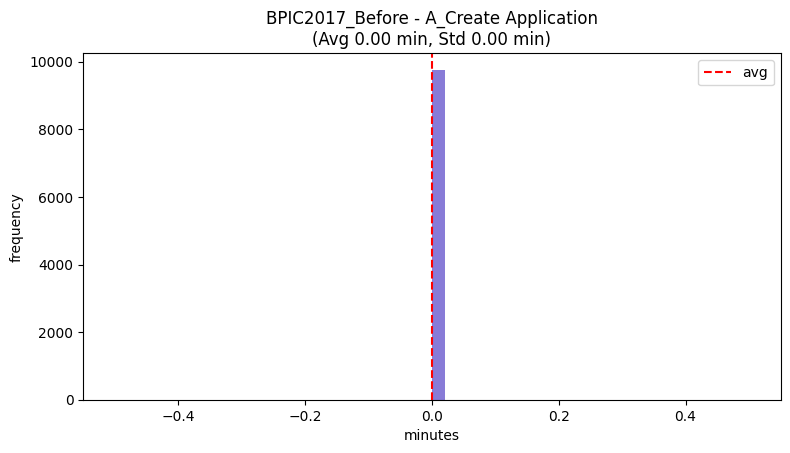

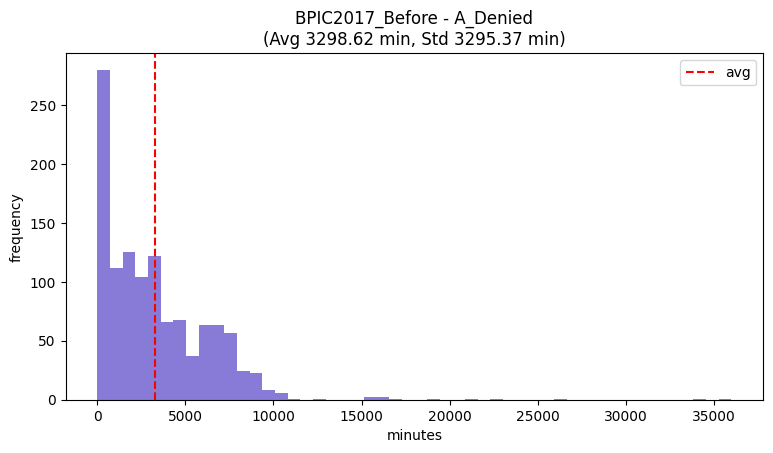

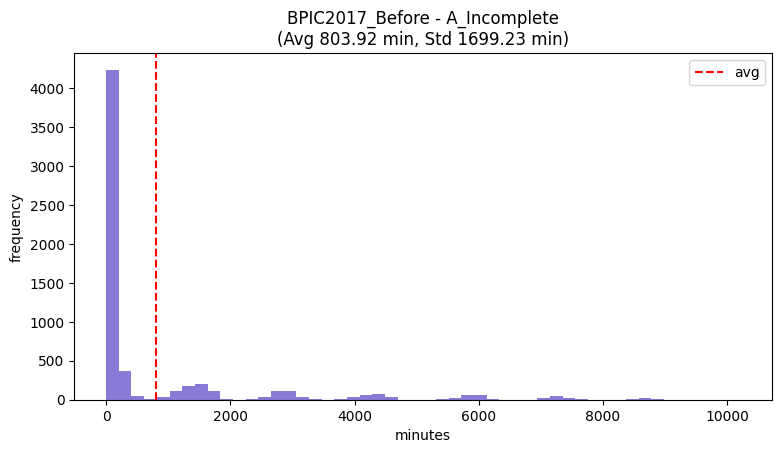

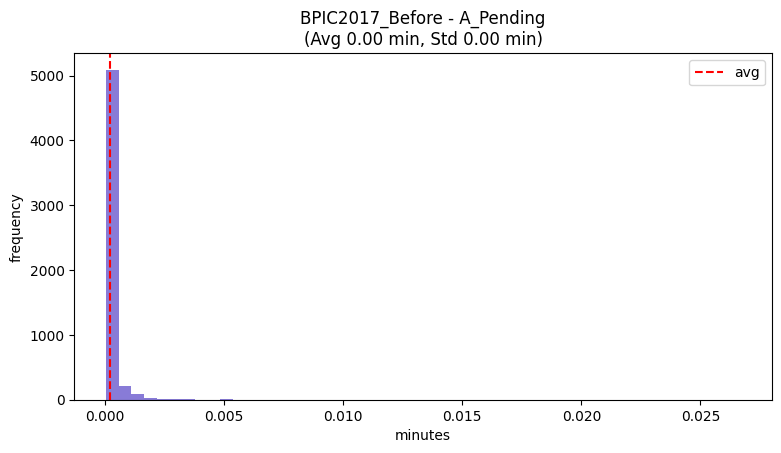

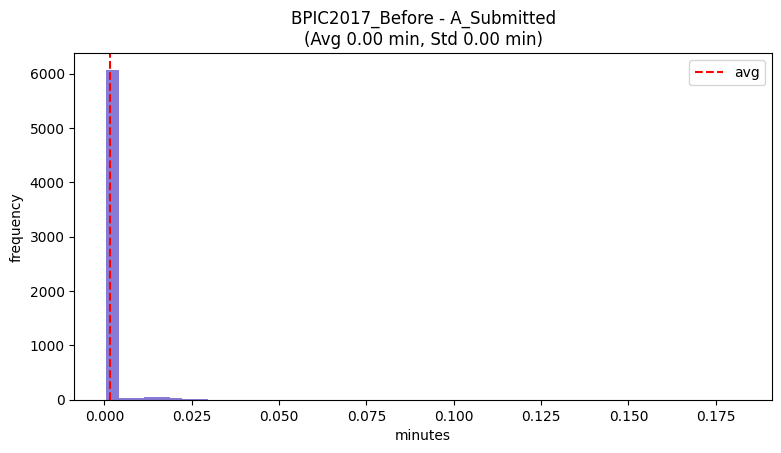

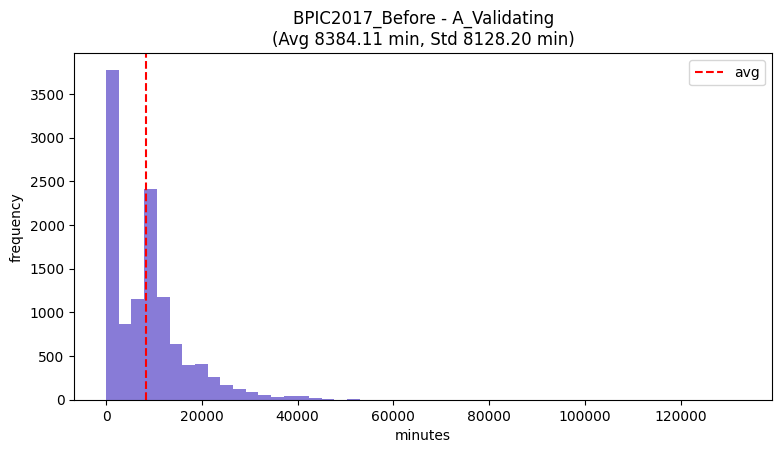

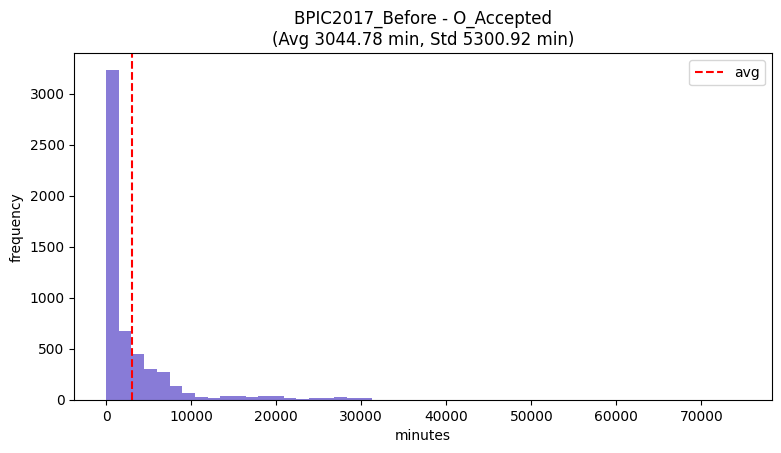

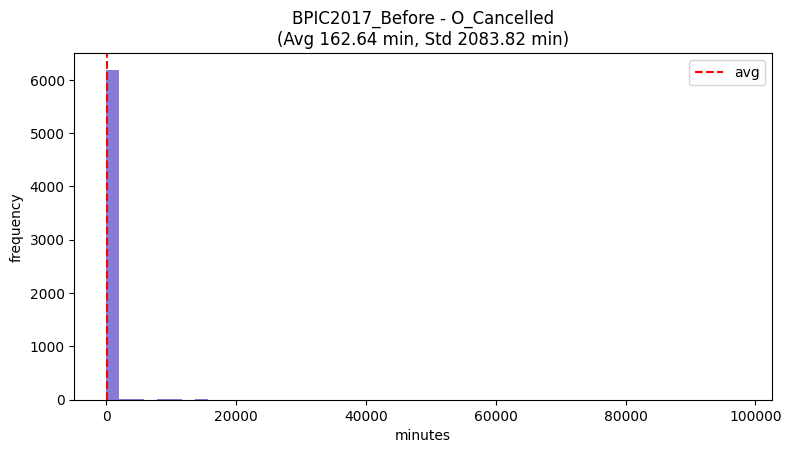

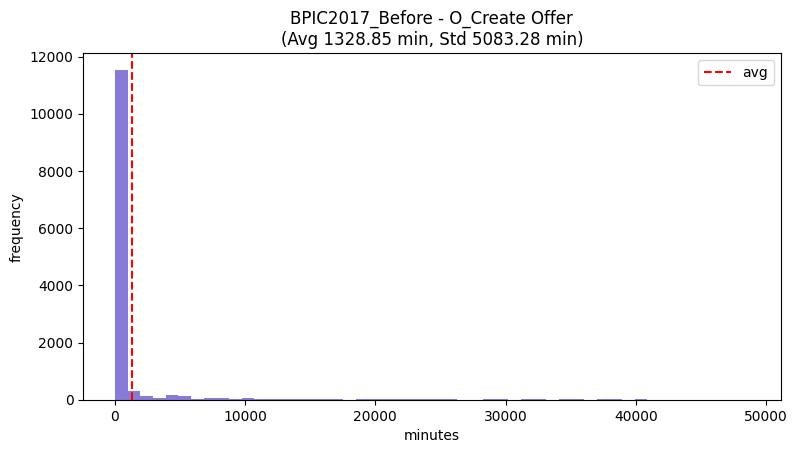

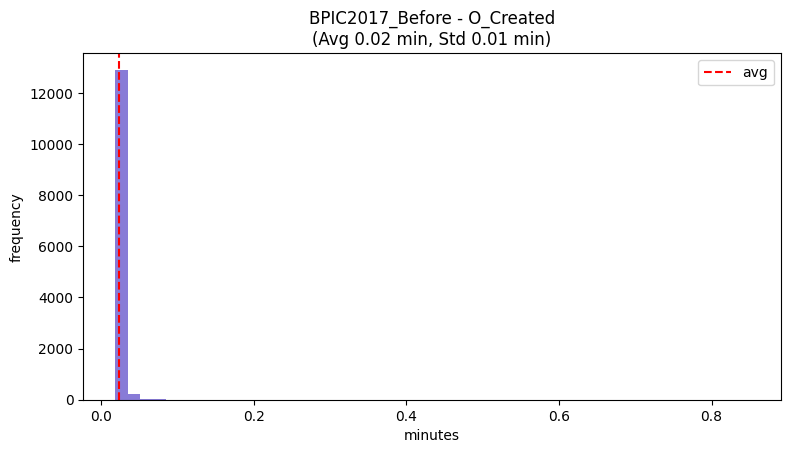

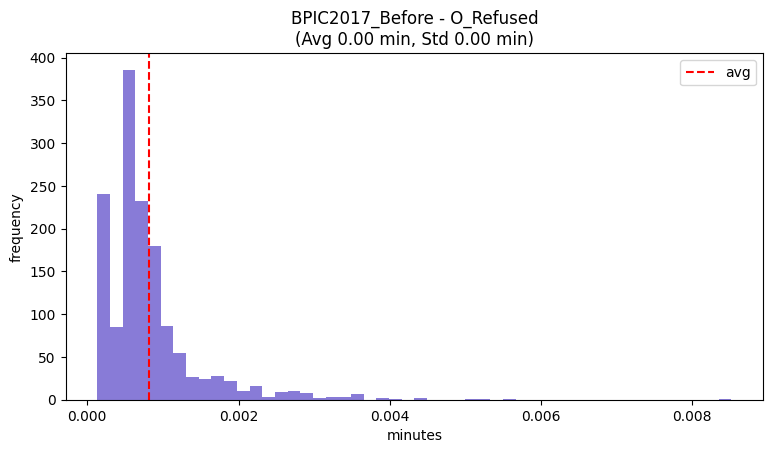

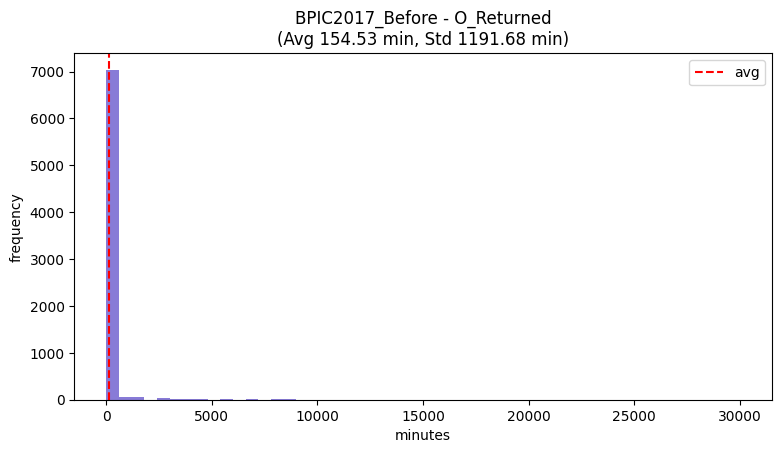

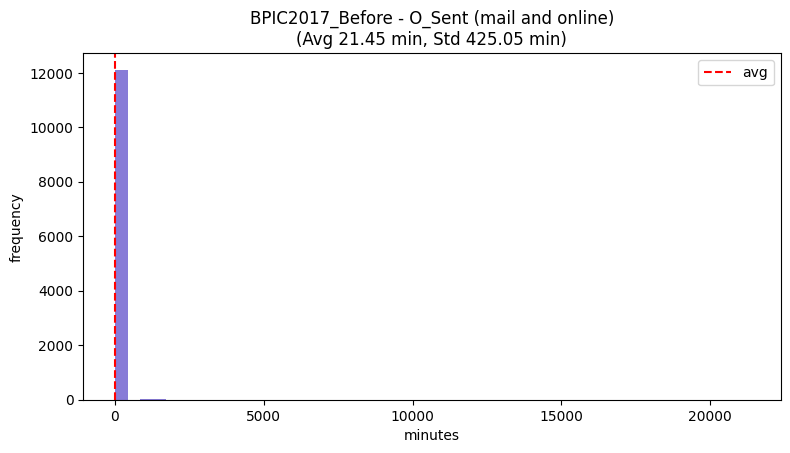

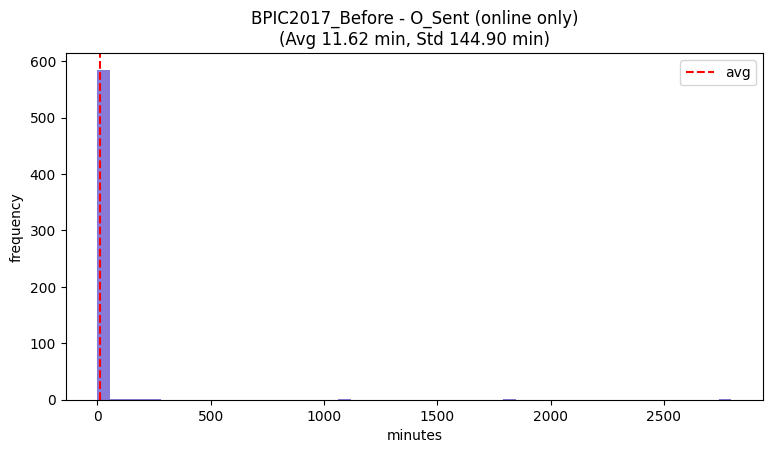

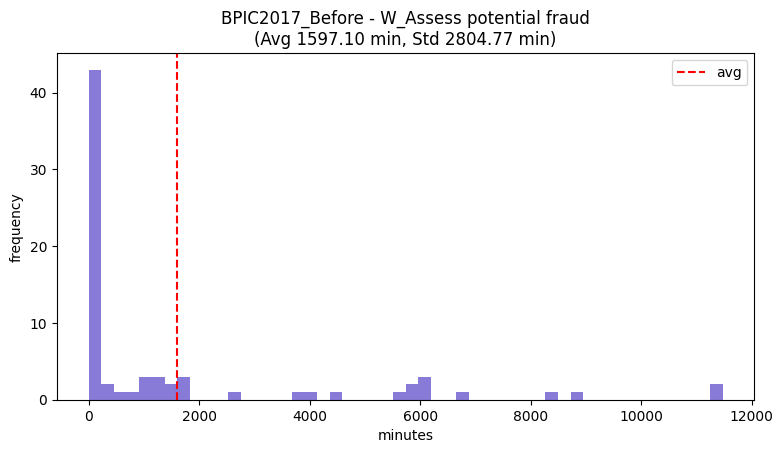

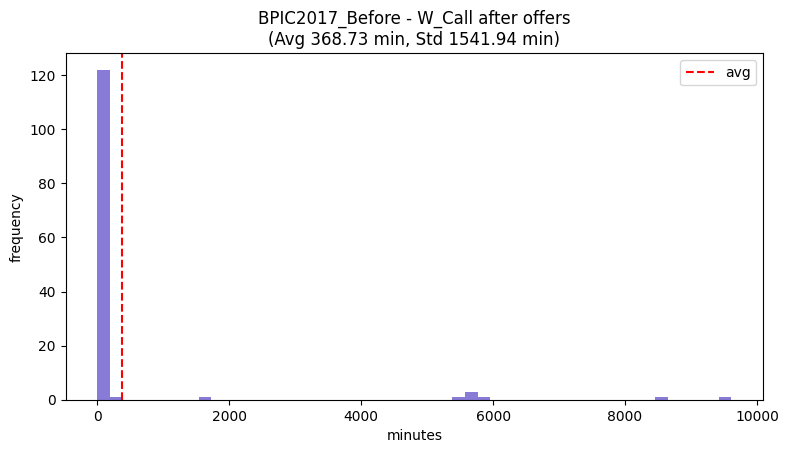

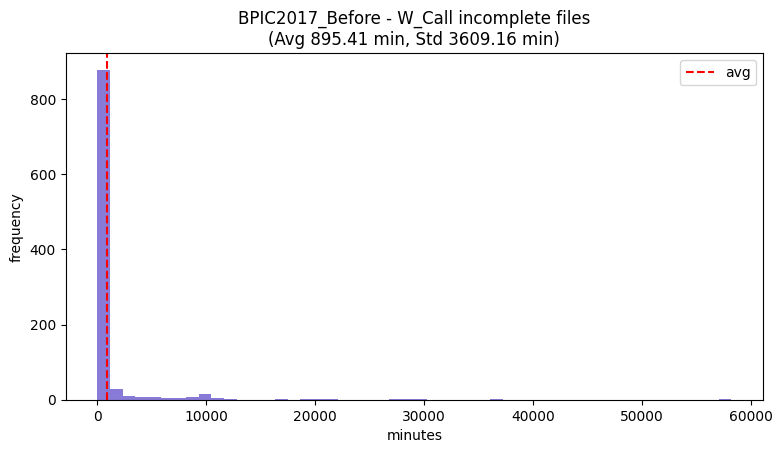

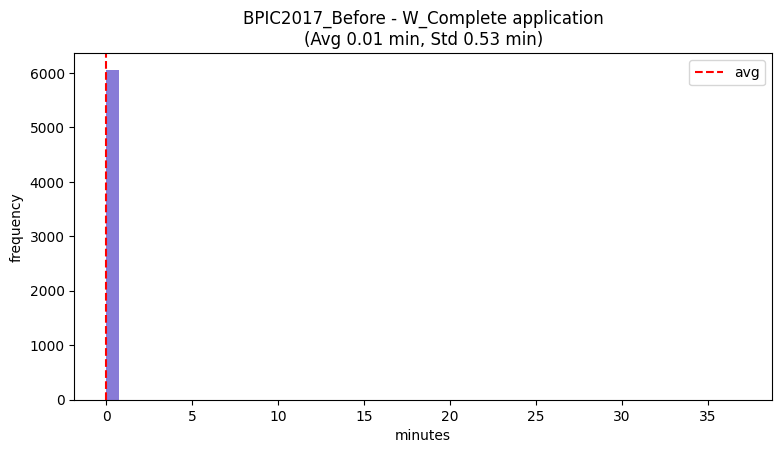

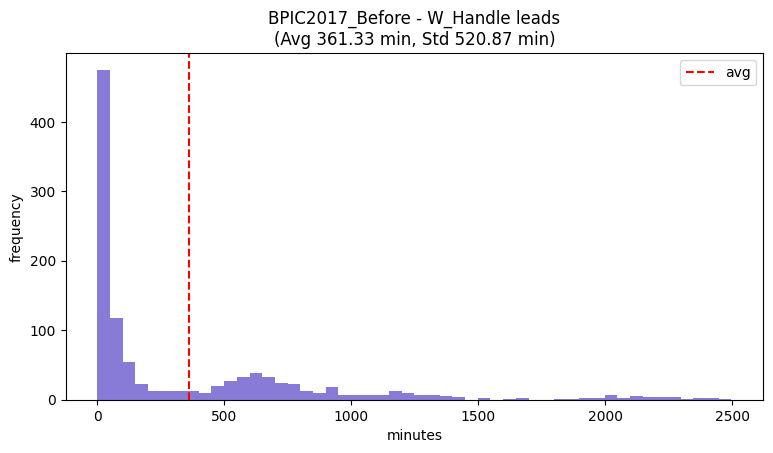

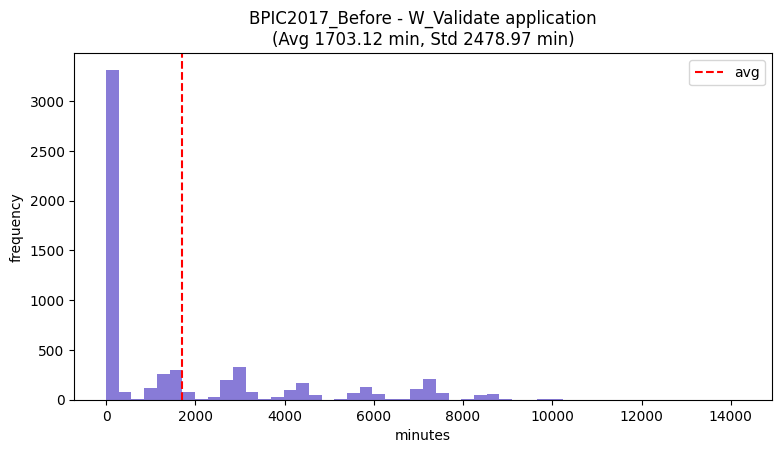

---
## Dataset: BPIC2017_After

### Overview

Number of cases: 7125
Number of events: 104849
Start activities: {'A_Create Application': 7125}
End activities: {'O_Cancelled': 2871, 'O_Refused': 632, 'A_Pending': 2945, 'W_Validate application': 452, 'W_Call after offers': 32, 'W_Assess potential fraud': 14, 'W_Call incomplete files': 117, 'W_Complete application': 23, 'A_Denied': 5, 'A_Cancelled': 34}


### Resources and organizational roles

Total number of distinct resources: 107
Number of discovered organizational roles: 14

Role 1: activities = ['A_Accepted', 'A_Complete', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Complete application']
    -> 85 resource(s): ['User_5', 'User_91', 'User_40', 'User_56', 'User_37', 'User_33', 'User_10', 'User_49', 'User_19', 'User_35', 'User_104', 'User_48', 'User_67', 'User_71', 'User_61', 'User_14', 'User_70', 'User_52', 'User_17', 'User_7', 'User_18', 'User_44', 'User_57', 'User_43', 'User_65', 'User_24', 'User_46', 'User_55', 'User_42', 'User_132', 'User_84', 'User_3', 'User_58', 'User_53', 'User_41', 'User_11', 'User_62', 'User_79', 'User_4', 'User_21', 'User_54', 'User_36', 'User_51', 'User_59', 'User_45', 'User_66', 'User_93', 'User_60', 'User_78', 'User_16', 'User_12', 'User_39', 'User_28', 'User_15', 'User_38', 'User_83', 'User_47', 'User_77', 'User_63', 'User_26', 'User_2', 'User_96', 'User_50', 'User_25', 'User_23', 'User_80', 'User_31', 'User_99', 'User_85'

### Case arrival frequency

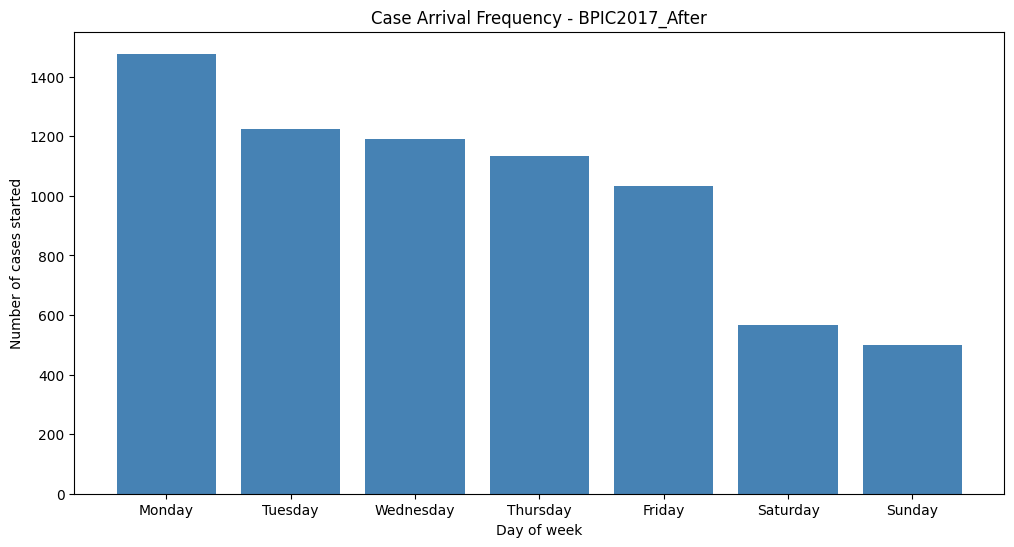

### Working-day and working-hour timetables (top 5 roles)

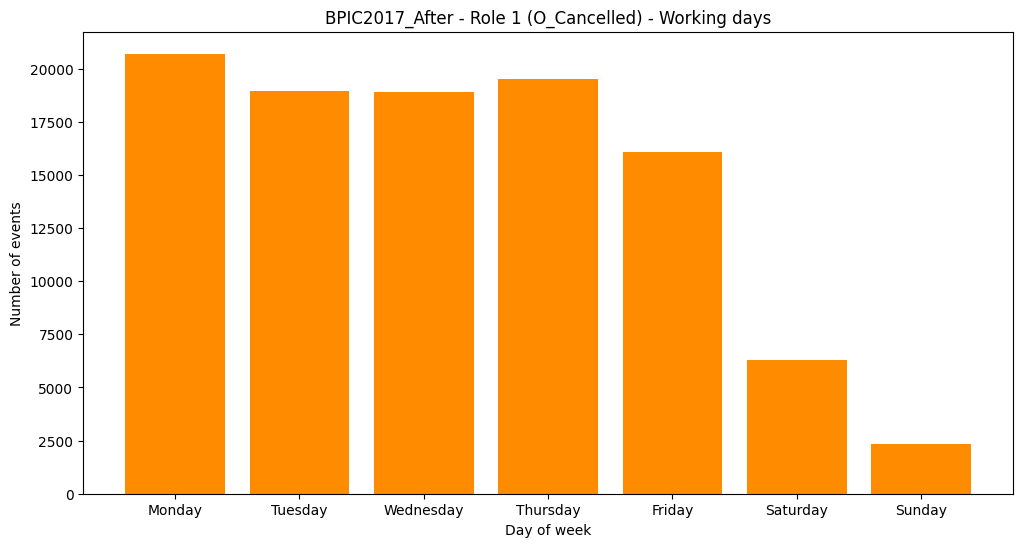

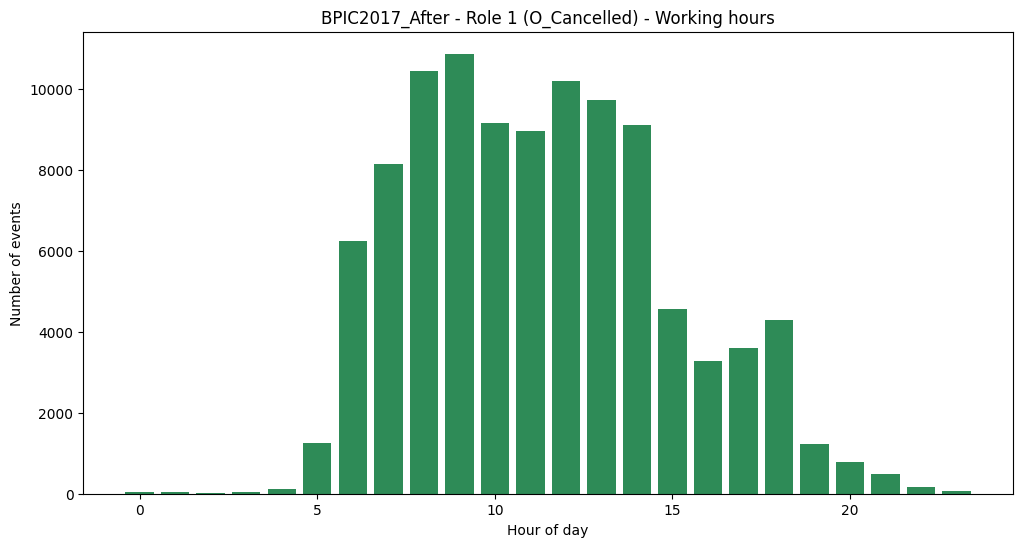

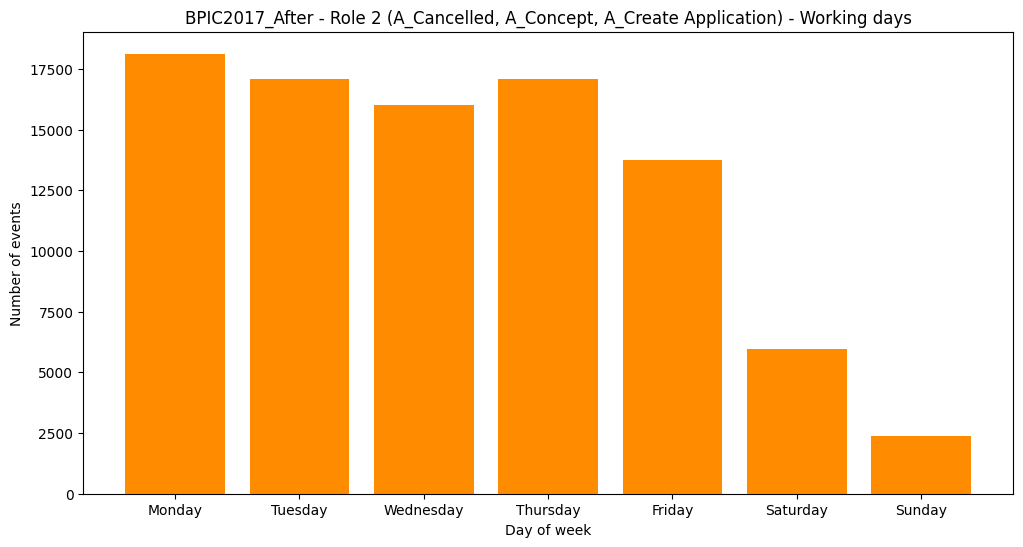

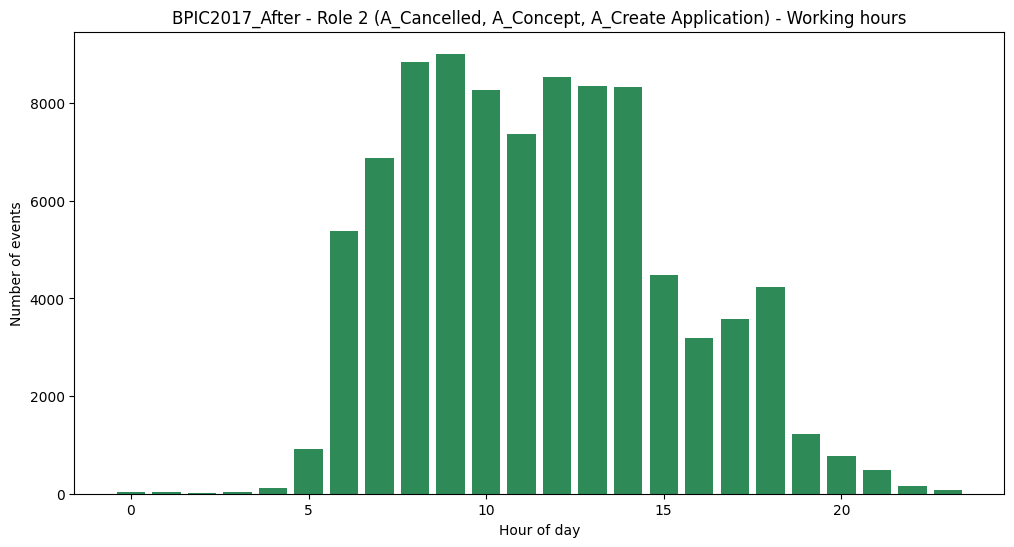

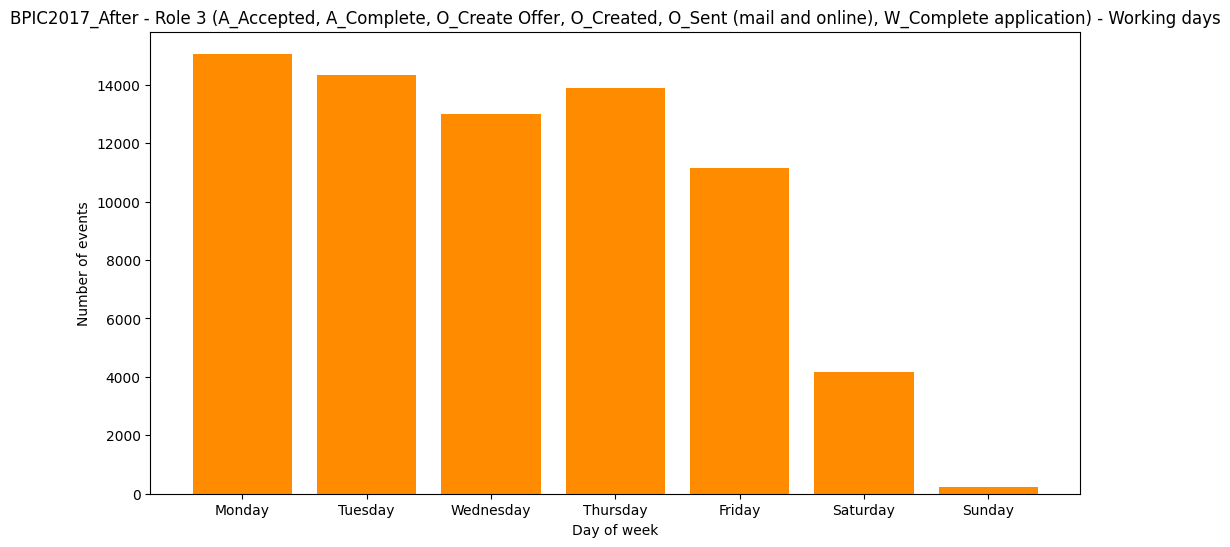

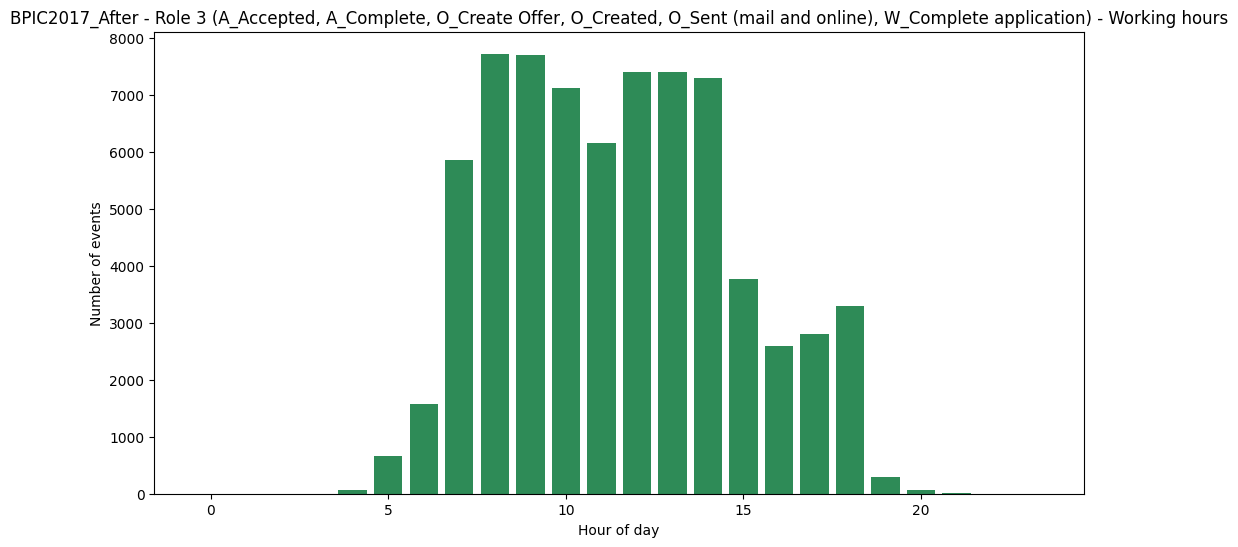

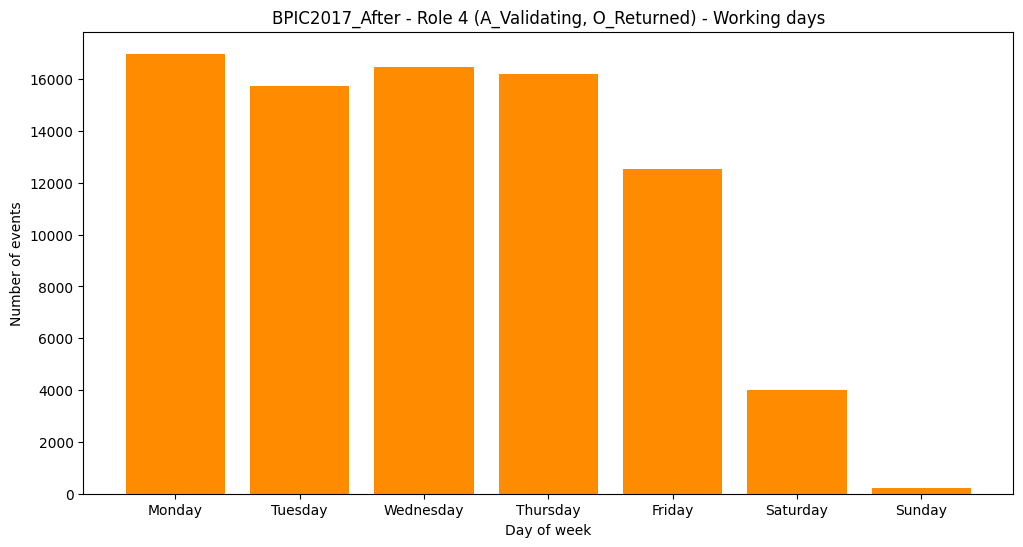

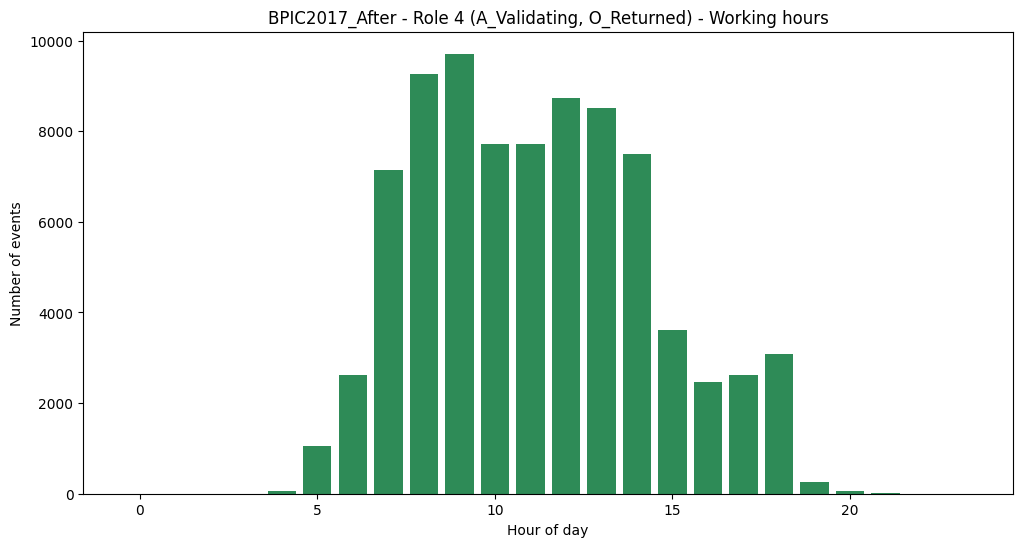

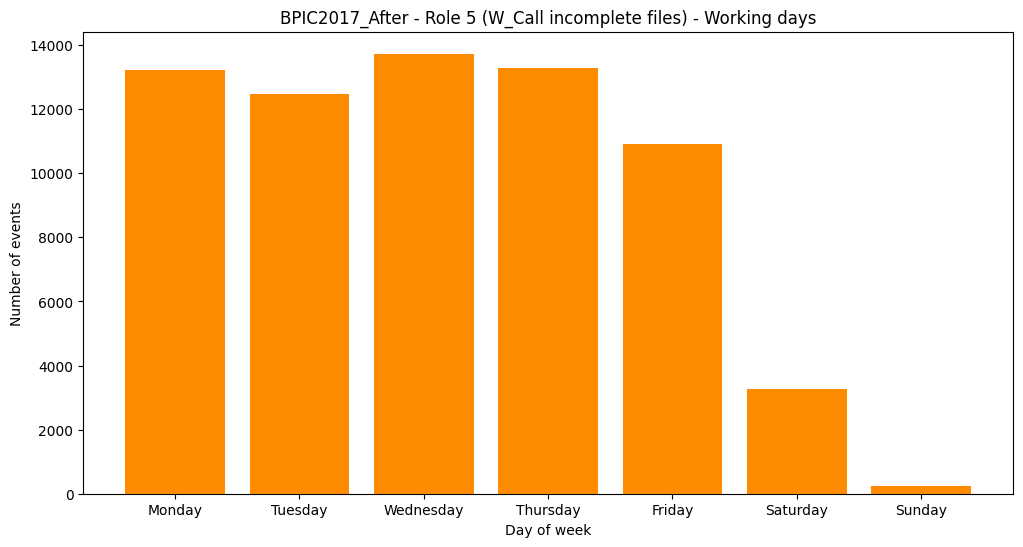

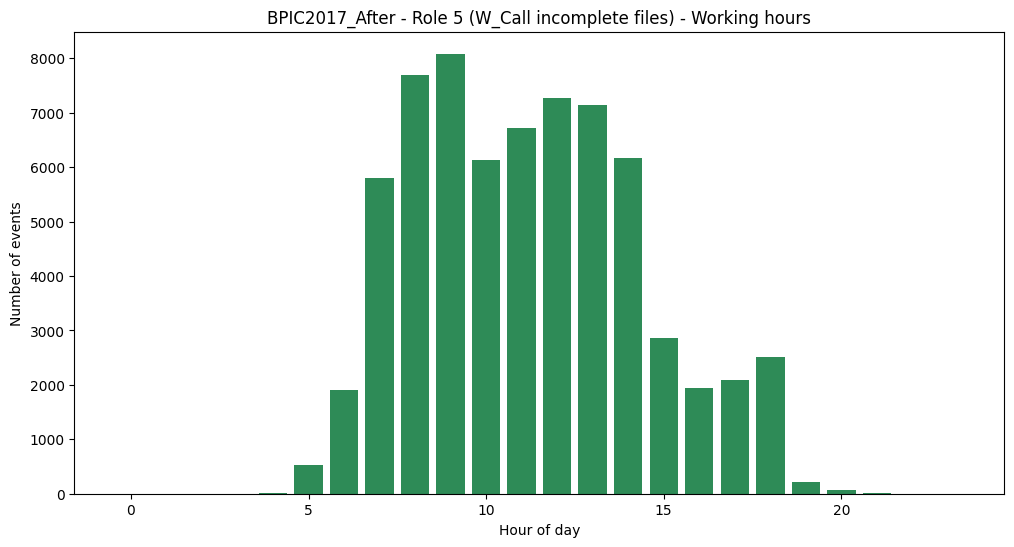

### Activity duration distributions

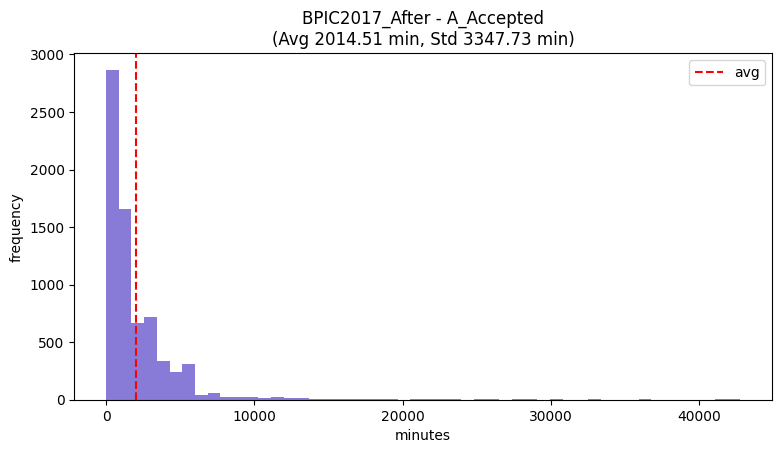

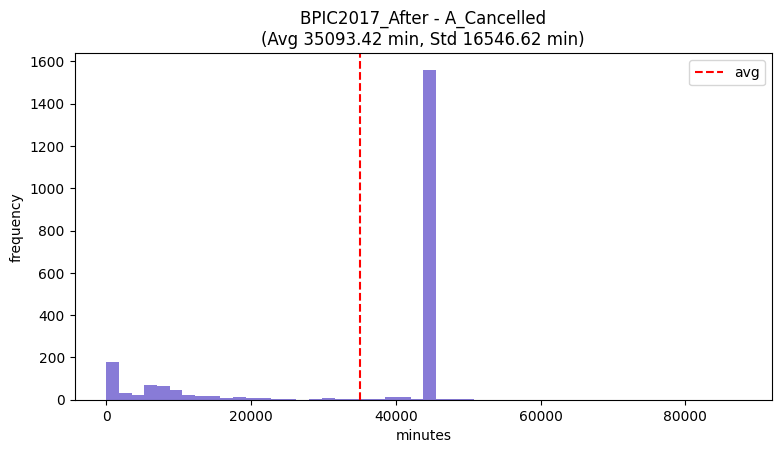

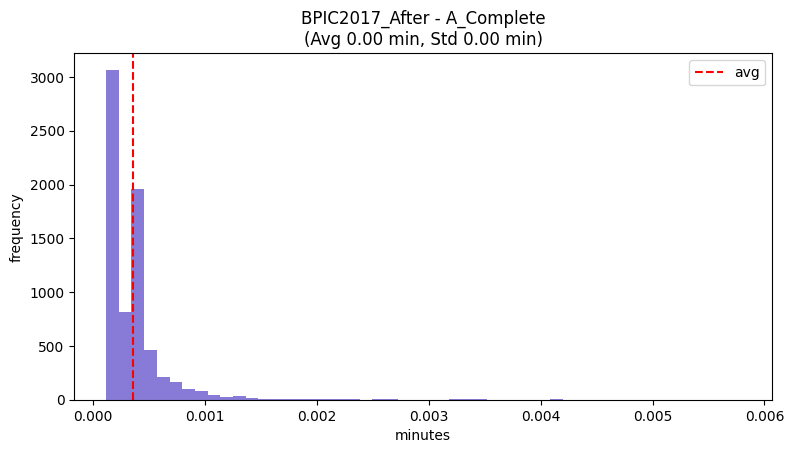

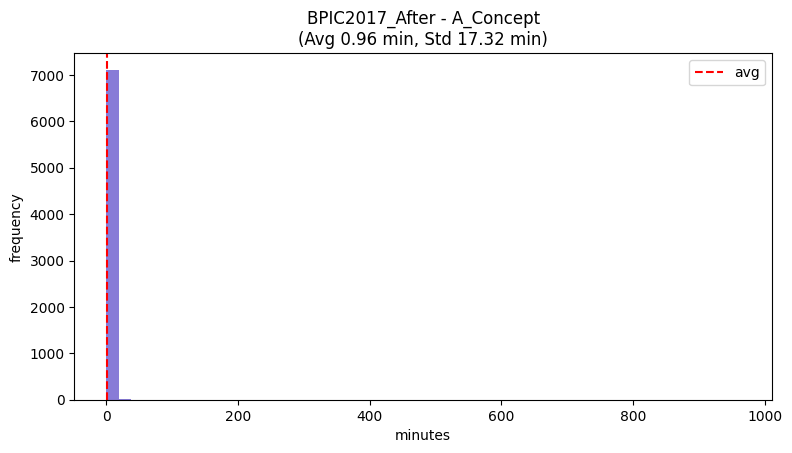

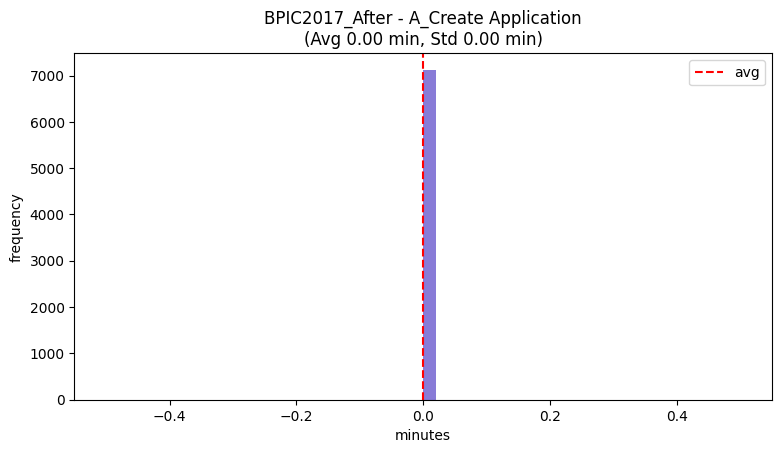

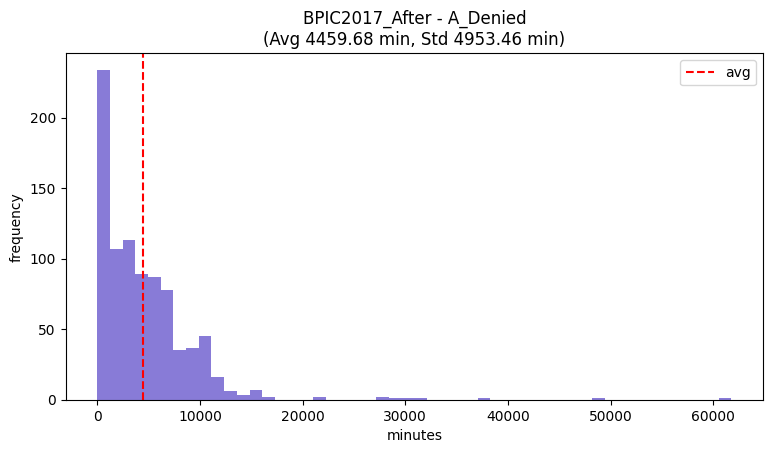

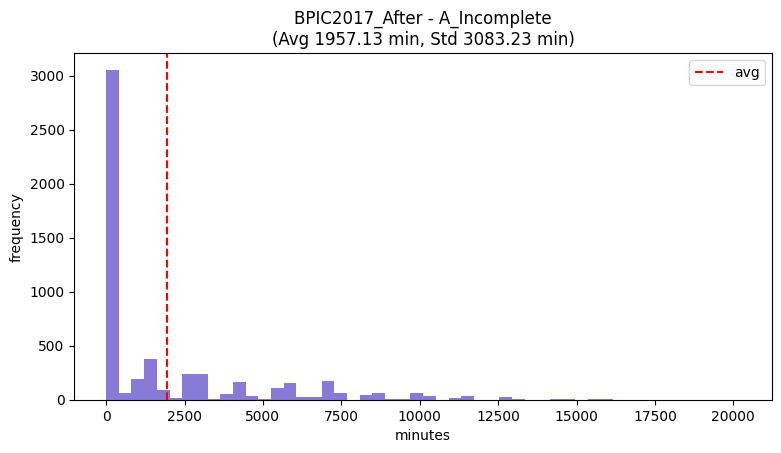

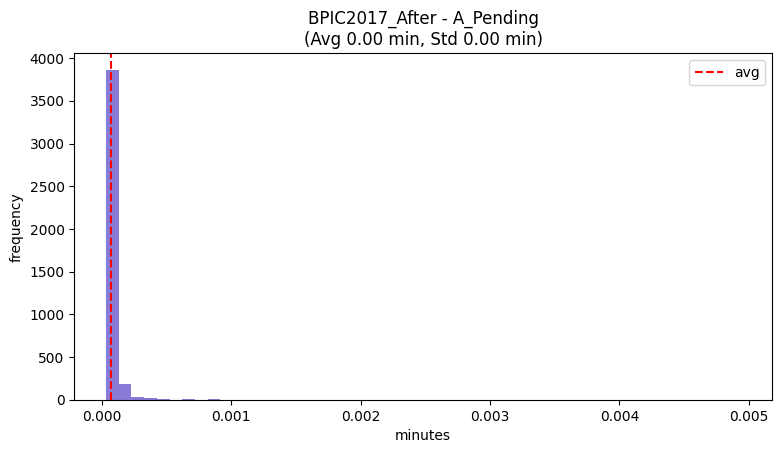

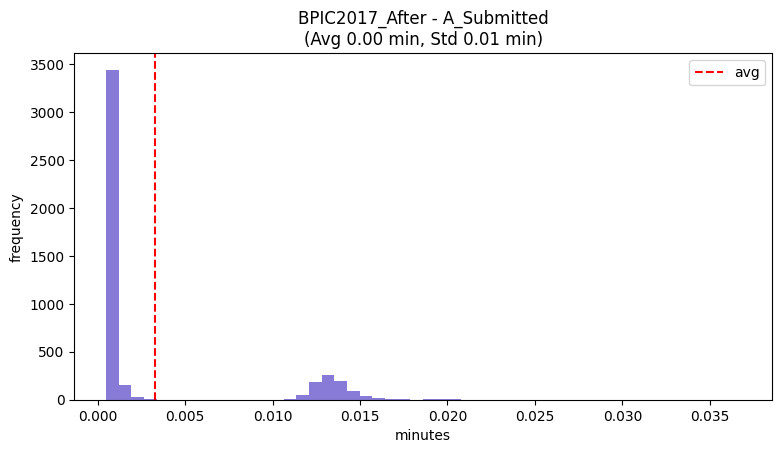

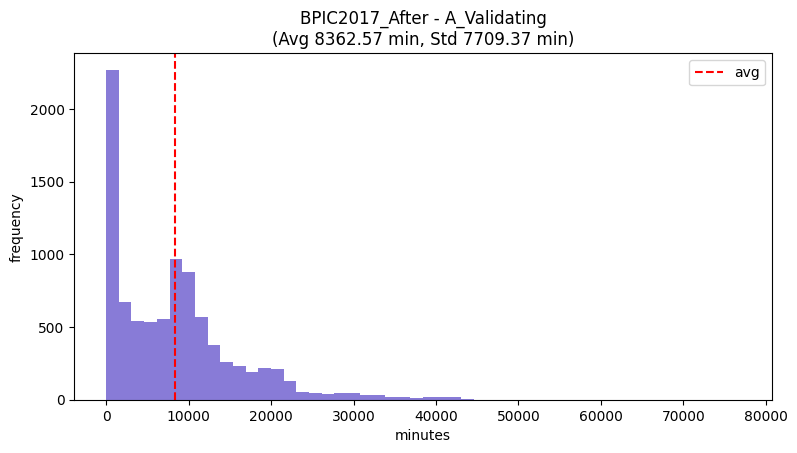

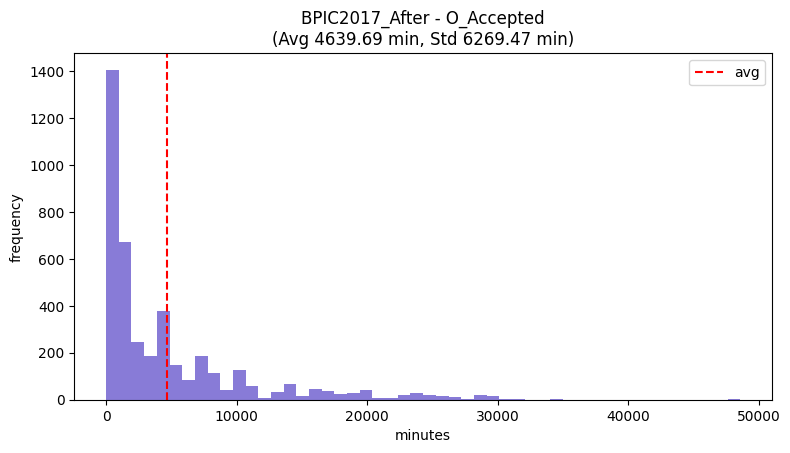

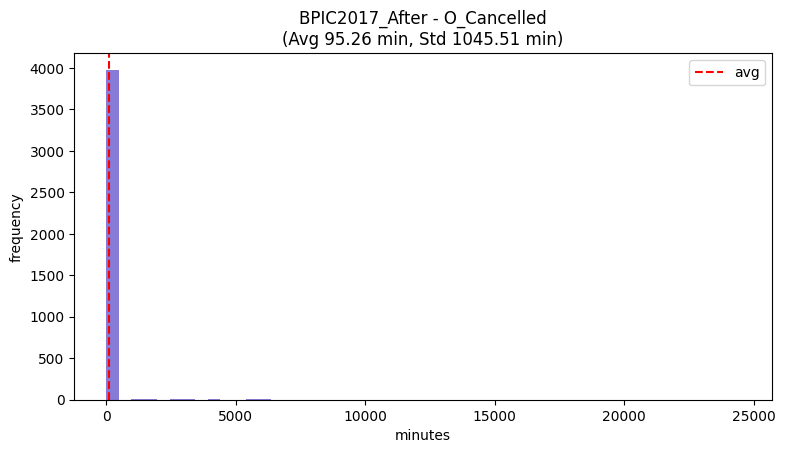

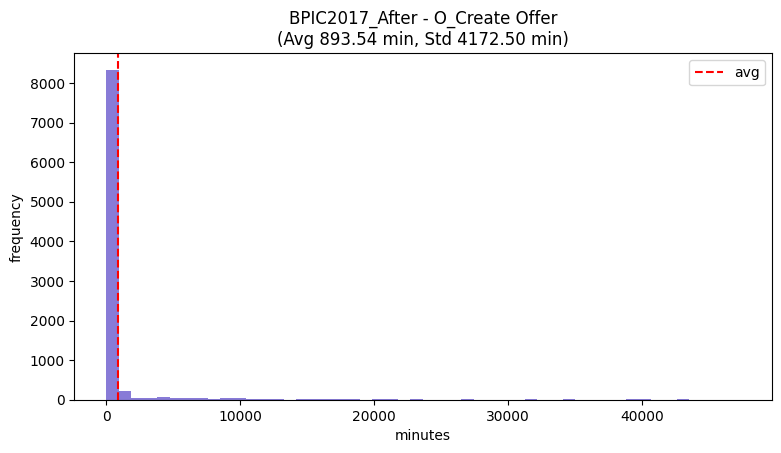

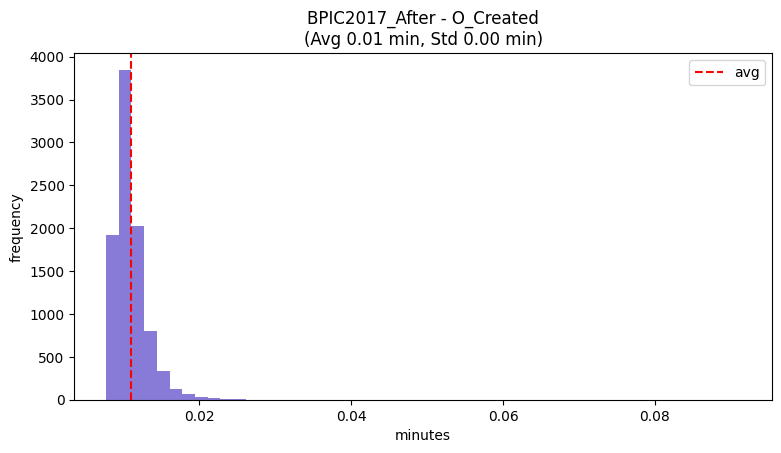

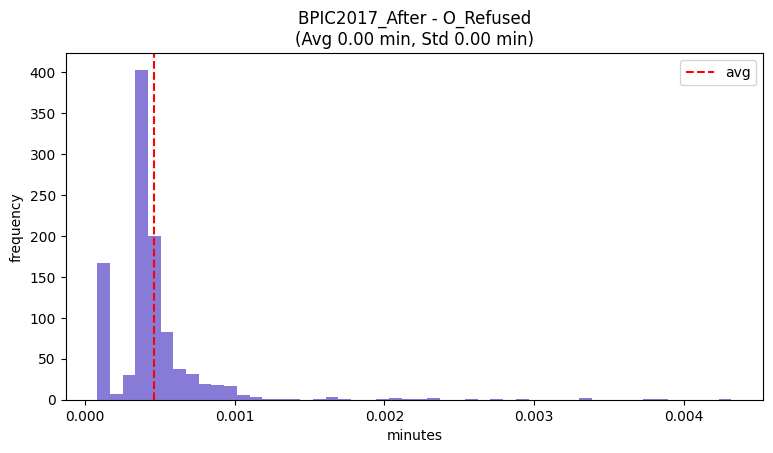

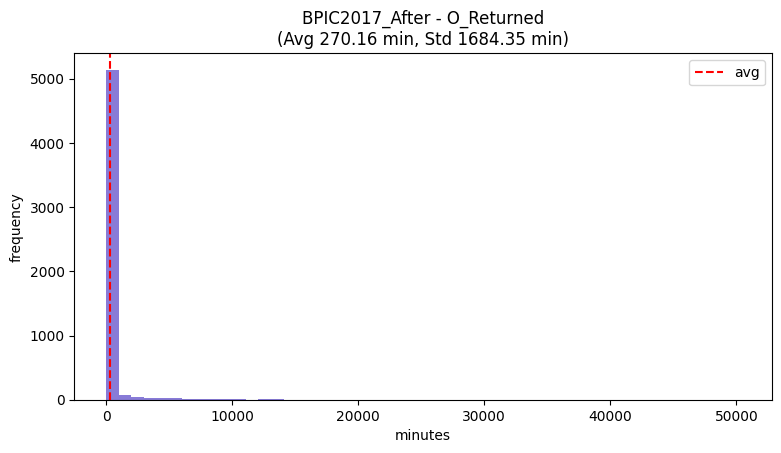

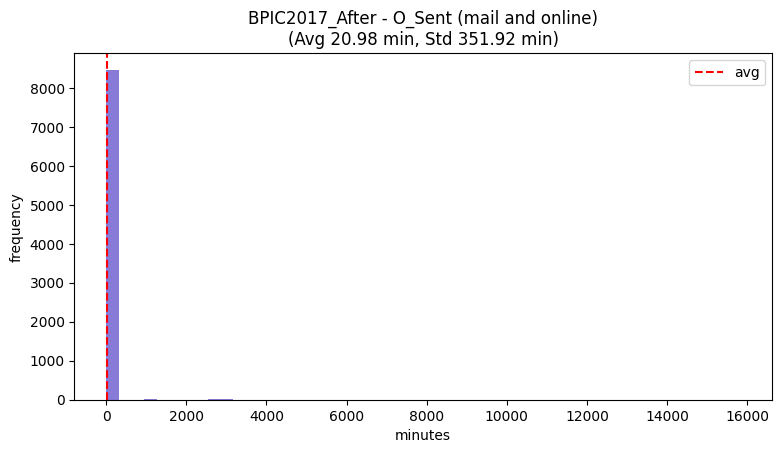

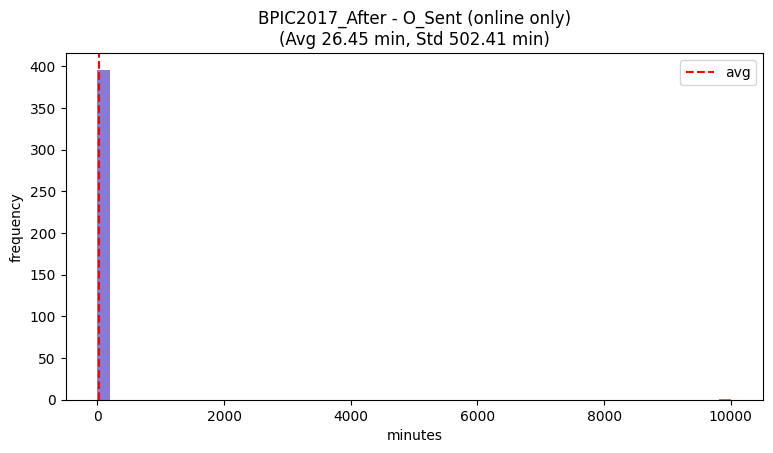

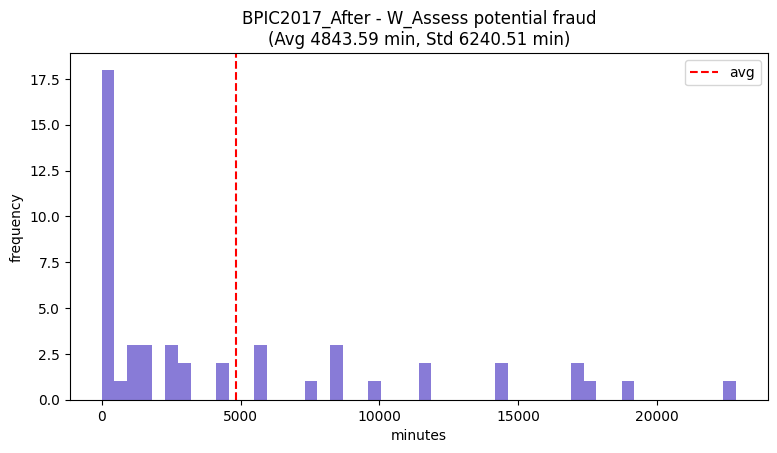

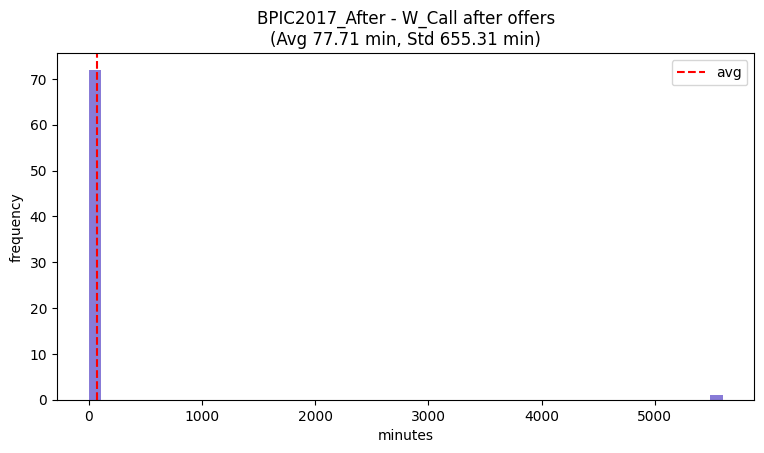

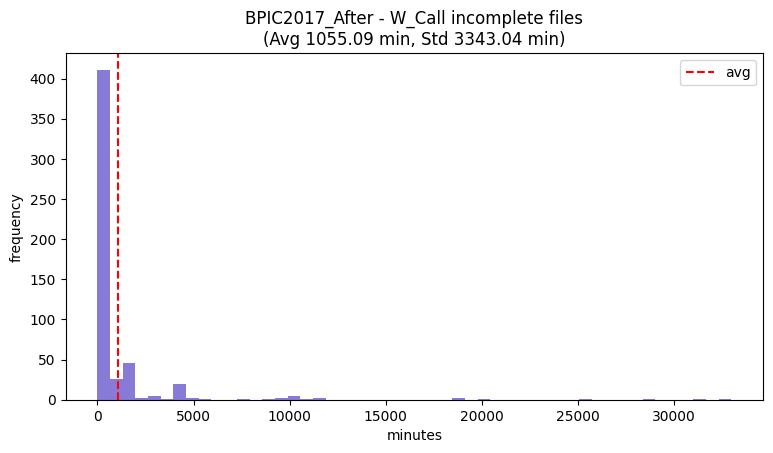

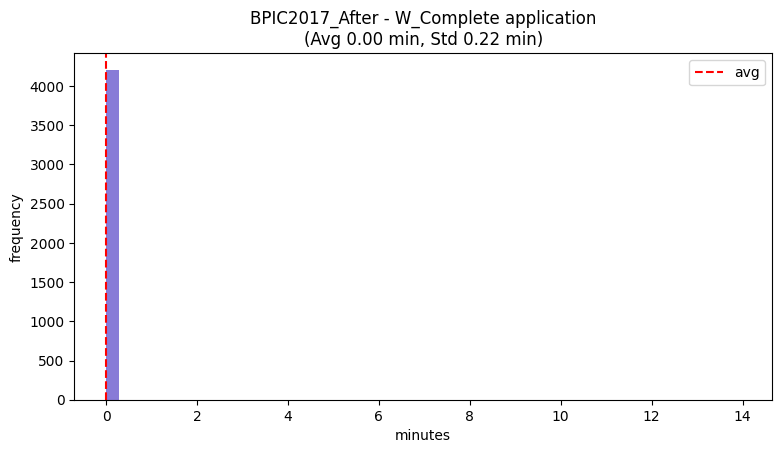

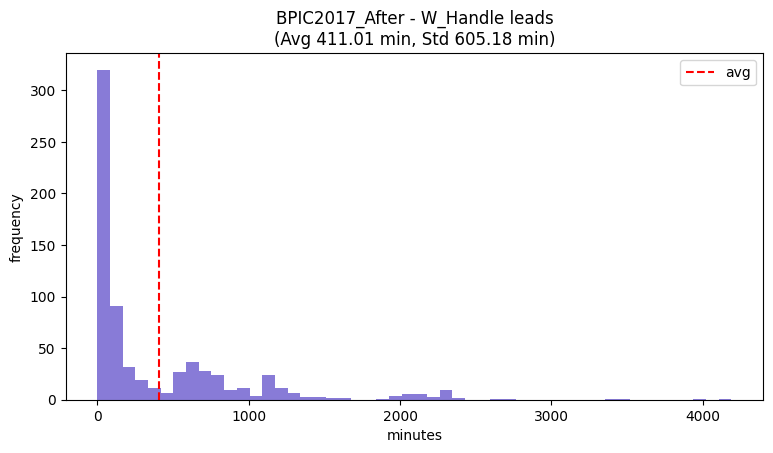

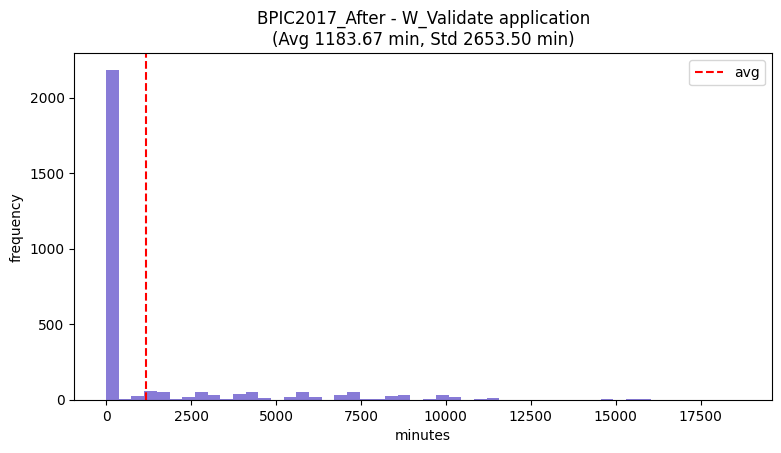

In [10]:
for dataset_name, log in event_logs.items():
    display(Markdown(f"---\n## Dataset: {dataset_name}"))
    df = get_log_dataframe(log)

    # --- Overview -----------------------------------------------------------
    display(Markdown("### Overview"))
    print(f"Number of cases: {df['case:concept:name'].nunique()}")
    print(f"Number of events: {len(df)}")
    print(f"Start activities: {pm4py.get_start_activities(log)}")
    print(f"End activities: {pm4py.get_end_activities(log)}")

    # --- Resources and organizational roles ----------------------------------
    display(Markdown("### Resources and organizational roles"))
    roles = print_resources_and_roles(log, df, dataset_name)

    # --- Case arrival frequency ----------------------------------------------
    display(Markdown("### Case arrival frequency"))
    plot_case_arrival_frequency(df, dataset_name)

    # --- Working-day / working-hour timetables per role -----------------------
    display(Markdown(f"### Working-day and working-hour timetables (top {TOP_N_ROLES} roles)"))
    sorted_roles = sorted(roles, key=lambda r: len(r.originator_importance), reverse=True)
    for i, role in enumerate(sorted_roles[:TOP_N_ROLES]):
        role_resources = list(role.originator_importance.keys())
        role_label = ", ".join(sorted(role.activities))
        plot_timetable_day(df, role_resources, f"{dataset_name} - Role {i + 1} ({role_label}) - Working days")
        plot_timetable_hour(df, role_resources, f"{dataset_name} - Role {i + 1} ({role_label}) - Working hours")

    # --- Activity duration distributions ---------------------------------------
    display(Markdown("### Activity duration distributions"))
    for activity in sorted(df["concept:name"].unique()):
        plot_activity_distribution(df, activity, dataset_name)

## 6. Exporting the full report as a single PDF

The inline output above becomes very long once printed for all four datasets, especially if every organizational role is plotted (not just the top `TOP_N_ROLES`). This section produces a single, well-organized **PDF report** (`process_mining_report.pdf`) instead, with one section per dataset:

- a title page,
- an overview page (cases, events, start/end activities),
- a page listing all resources and organizational roles,
- the case arrival frequency plot,
- the working-day/working-hour timetable for **every** organizational role (no `TOP_N_ROLES` limit here),
- the duration distribution of every activity.

This cell **reuses the exact same functions** defined in Section 4 (`get_log_dataframe`, `print_resources_and_roles`, `plot_case_arrival_frequency`, `plot_timetable_day`, `plot_timetable_hour`, `plot_activity_distribution`) — it simply redirects their `print()` output and `plt.show()` calls into PDF pages instead of the notebook, so this cell's own notebook output stays short (just a progress log).

In [ ]:
import io
import contextlib
import textwrap
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

REPORT_PDF_PATH = str(base_dir / "simulation" / "discovery_report.pdf")


def add_text_page(pdf, title, text, fontsize=9, max_lines_per_page=50):
    """Renderizza un blocco di testo wrappato correttamente entro i margini A4."""
    # Larghezza utile della pagina: A4 width = 8.27 in.
    # Margine sx=0.06, dx=0.94 -> Larghezza disponibile ~7.28 in.
    # Con monospace a fontsize 9, ~80-85 caratteri è il limite massimo sicuro.
    max_char_per_line = 82  

    wrapped_lines = []
    for line in text.splitlines():
        if not line.strip():
            wrapped_lines.append("")
            continue
        wrapped = textwrap.wrap(
            line, 
            width=max_char_per_line, 
            replace_whitespace=False, 
            drop_whitespace=False
        )
        wrapped_lines.extend(wrapped if wrapped else [""])

    if not wrapped_lines:
        wrapped_lines = [""]

    for start in range(0, len(wrapped_lines), max_lines_per_page):
        chunk = wrapped_lines[start:start + max_lines_per_page]
        page_title = title if start == 0 else f"{title} (continued)"

        fig = plt.figure(figsize=(8.27, 11.69))  # A4 Portrait
        fig.suptitle(page_title, fontsize=14, fontweight="bold", y=0.96)
        
        # Margini sicuri: lasciamo il 6% a sinistra e destra, 5% in basso e 8% in alto
        ax = fig.add_axes([0.06, 0.05, 0.88, 0.87])
        ax.axis("off")
        
        # Rendering con coordinate relative alla bounding box dell'asse
        ax.text(
            0.0, 1.0, 
            "\n".join(chunk), 
            transform=ax.transAxes,
            va="top", 
            ha="left", 
            fontsize=fontsize, 
            family="monospace"
        )
        pdf.savefig(fig)
        plt.close(fig)


def add_section_title_page(pdf, title, subtitle=""):
    """Renderizza una pagina di copertina/sezione con testo centrato."""
    fig = plt.figure(figsize=(8.27, 11.69))
    
    # Tronchiamo o wrappiamo il titolo se troppo lungo per evitare che esca dalla pagina
    wrapped_title = "\n".join(textwrap.wrap(title, width=30))
    fig.text(0.5, 0.55, wrapped_title, fontsize=24, fontweight="bold", ha="center", va="center")
    
    if subtitle:
        wrapped_subtitle = "\n".join(textwrap.wrap(subtitle, width=50))
        fig.text(0.5, 0.45, wrapped_subtitle, fontsize=12, ha="center", va="center")
        
    pdf.savefig(fig)
    plt.close(fig)


def truncate_string(text, max_length=60):
    """Tronca una stringa se supera max_length aggiungendo '...'"""
    return text if len(text) <= max_length else text[:max_length - 3] + "..."


with PdfPages(REPORT_PDF_PATH) as pdf:

    add_section_title_page(
        pdf,
        "Process Mining Analysis Report",
        "Resources, Roles, Timetables and Activity Distributions",
    )

    for dataset_name, log in event_logs.items():
        print(f"Generating report section for {dataset_name} ...")
        df = get_log_dataframe(log)

        add_section_title_page(pdf, dataset_name)

        # --- Overview ------------------------------------------------------
        overview_text = (
            f"Number of cases: {df['case:concept:name'].nunique()}\n"
            f"Number of events: {len(df)}\n"
            f"Start activities: {pm4py.get_start_activities(log)}\n"
            f"End activities: {pm4py.get_end_activities(log)}"
        )
        add_text_page(pdf, f"{dataset_name} - Overview", overview_text)

        # --- Resources and organizational roles ----------------------------
        stdout_buffer = io.StringIO()
        with contextlib.redirect_stdout(stdout_buffer):
            roles = print_resources_and_roles(log, df, dataset_name)
        add_text_page(pdf, f"{dataset_name} - Resources and Organizational Roles", stdout_buffer.getvalue())

        # --- Plots ---------------------------------------------------------
        original_show = plt.show
        plt.show = lambda *args, **kwargs: (pdf.savefig(plt.gcf()), plt.close(plt.gcf()))
        
        try:
            plot_case_arrival_frequency(df, dataset_name)

            # Timetables per ruolo (con gestione del titolo lungo)
            for i, role in enumerate(roles):
                role_resources = list(role.originator_importance.keys())
                
                # Tronchiamo l'etichetta del ruolo se contiene troppe attività
                raw_role_label = ", ".join(sorted(role.activities))
                safe_role_label = truncate_string(raw_role_label, max_length=50)

                plot_timetable_day(
                    df, 
                    role_resources, 
                    f"{dataset_name} - Role {i + 1} ({safe_role_label}) - Working days"
                )
                plot_timetable_hour(
                    df, 
                    role_resources, 
                    f"{dataset_name} - Role {i + 1} ({safe_role_label}) - Working hours"
                )

            # Activity duration distributions
            for activity in sorted(df["concept:name"].unique()):
                plot_activity_distribution(df, activity, dataset_name)
                
        finally:
            plt.show = original_show

print(f"\nReport saved to: {Path(REPORT_PDF_PATH).resolve()}")

Generating report section for BAC ...
Generating report section for BPIC2012 ...
Generating report section for BPIC2017_Before ...
Generating report section for BPIC2017_After ...

Report saved to: C:\Users\Utente\Desktop\tesi magistrale\Code\2-gelmini-multi\simulation\process_mining_report.pdf


## 7. Process Model Discovery and Hyperparameter Optimization

In this section, we focus on discovering the underlying process models from our preprocessed event logs using the **Split Miner** algorithm. To ensure the highest quality and representativeness of our discovered models, we introduce an automated hyperparameter tuning step using Bayesian Optimization via **Optuna**.

Instead of relying on predefined values, we systematically optimize the algorithm's two key parameters: $\epsilon$ and $\eta$. The objective function is designed to maximize the **F-score**, a harmonic mean that balances two critical alignment-based metrics: **log fitness** (how well the model reproduces the behaviors observed in the log) and **precision** (how well the model restricts behaviors not seen in the log). 

For each case study, this automated optimization process will:
1. **Explore the Search Space:** Run 30 optimization trials to evaluate different combinations of $\epsilon$ and $\eta$ (ranging from 0.0 to 1.0).
2. **Evaluate Performance:** Calculate the fitness, precision, and resulting F-score for each parameter combination.
3. **Generate the Optimal Model:** Re-discover the final Petri net using the configuration that yielded the highest F-score.
4. **Export and Visualize:** Export the optimal model as a standard `.pnml` file and generate a high-resolution `.jpg` visualization. The visual output includes custom graph layout optimizations—such as label cleaning, bounding box removal, and node margin adjustments—to ensure a clear and highly readable representation.

The code regarding this part is in the file `petri_nets_discovery.py`. The output of that code is shown in the following table:
| Case Study | Tentativi Totali | Tentativi Riusciti | $\epsilon$  | $\eta$  | Fitness | Precision | F-score |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **BAC** | 30 | 30 | 0.0 | 0.8 | 0.9884 | 0.9002 | 0.9422 |
| **BPI12** | 30 | 25 | 0.0 | 1.0 | 0.8105 | 0.7284 | 0.7673 |
| **bpi17_after** | 30 | 28 | 0.5 | 0.3 | 0.9397 | 0.8476 | 0.8913 |
| **bpi17_before** | 30 | 27 | 0.0 | 0.3 | 0.9574 | 0.8707 | 0.9120 |


## 8. Resource Discovery 